# Get additional annotation info for SNPs

Here are some websites that are great (some of the data I can't get via API):
1. [RegulomeDB](https://www.regulomedb.org/regulome-search?regions=chr17%3A9557840-9557841&genome=GRCh38/thumbnail=chromatin) (from ENCODE)  -- No API
	* Genome Browser
	* ChIP data
	* Chromatin State (Enhancer info via ChromHMM by Organ)
	* Accessibility
	* Motifs
	* QTLs
2. [Open Targets](https://www.regulomedb.org/regulome-search?regions=chr17%3A9557840-9557841&genome=GRCh38/thumbnail=chromatin)
	* Variant effect
	* Molecular Structure
	* Transcript Consequences
	* ClinVar
	* UniProt variants
	* GWAS Credible Sets
	* molQTL Credible Sets
	* Pharmacogenetics
3. [3DSNP v2.0](https://omic.tech/3dsnpv2/detail.do?name=rs429358&chrom=chr19#section4), [Paper](https://doi.org/10.1093/nar/gkab1008)
	* Population frequency (Sequential information)
	* Genome Browser and Circos (in hg19)
	* Population genetic stats (haplotype & fixation index from 1000Genomes)
	* ClinVar
	* Linear closest gene
	* 3D interacting gene
	* eQTL
	* 3D interacting SNP
	* Chromatin State (Enhancer info via ChromHMM by Organ)
	* Conservation (via PhyP scores)

Other info used via APIs: ClinVar (directly), ENSEMBL (to get variant allele info), GWAS Catalog

In [19]:
import requests
import pandas as pd #!pip3 install openpyxl for read_excel
from myvariant import MyVariantInfo #pip3 install myvariant
import time
import re
import numpy as np

### Functions

In [32]:

#####################################
###### PREP RSID DATA ###############
def rsid_to_variantid_ncbi(rsid):
    """
    Convert an rsID to Open Targets variant ID(s) using the NCBI Variation API.

    Parameters
    ----------
    rsid : str
        SNP identifier in rsID format (e.g., "rs429358").

    Returns
    -------
    list of str
        List of variant IDs in Open Targets format ("chr_pos_ref_alt") for GRCh38 assembly.
        Returns an empty list if no valid placement is found.
    """
    url = f"https://api.ncbi.nlm.nih.gov/variation/v0/beta/refsnp/{rsid.lstrip('rs')}"
    r = requests.get(url)
    if r.status_code != 200:
        raise ValueError(f"Error {r.status_code}: {r.text}")

    data = r.json()
    # Each placement corresponds to a genome assembly (GRCh37, GRCh38, etc.)
    placements = data.get("primary_snapshot_data", {}).get("placements_with_allele", [])
    gr38_variant_ids = []
    
    for p in placements:
        if not p.get("is_ptlp"):  # only want top-level placement
            continue
        assembly = p.get("placement_annot", {}).get("seq_id_traits_by_assembly", [{}])[0].get("assembly_name", "")
        if "GRCh38" not in assembly:
            continue

        for allele in p.get("alleles", []):
            spdi = allele.get("allele", {}).get("spdi", {})
            if not spdi:
                continue
            # if no change then skip
            if spdi["deleted_sequence"] == spdi["inserted_sequence"]:
                continue
            chrom = spdi["seq_id"].replace("NC_0000", "").replace("NC_", "")
            # convert NC accession to chromosome number
            chrom = chrom.split(".")[0]
            pos = spdi["position"] + 1  # NCBI SPDI is 0-based
            ref = spdi["deleted_sequence"] if spdi["deleted_sequence"] else "-"
            alt = spdi["inserted_sequence"] if spdi["inserted_sequence"] else "-"
            gr38_variant_ids.append(f"{chrom}_{pos}_{ref}_{alt}")

    return gr38_variant_ids

# Example
print(rsid_to_variantid_ncbi("rs429358"))


######################################
###### VARIANT EFFECTS ###############

def query_opentargets_varianteffectENSpredictor(variant_id):
	"""
    Query Open Targets for QTL credible sets associated with a variant.

    Parameters
    ----------
    variant_id : str
        Variant identifier in Open Targets format ("chr_pos_ref_alt", e.g., "19_45411941_C_T").
    size : int, optional
        Page size (number of results to fetch per request).
    index : int, optional
        Page index (0 = first page).

    Returns
    -------
    df of variables of interest: 
		- Variant
		- Pred_Consequence: predicted consequence (e.g. missense variant)
		- distFtpt: distance from footprint (could be one of many like TF motif)
		- distTSS: distance from the target's TSS
		- Pred_target: target gene/protein
		- Consequence_score: Ensembl consequence/rank score where 0 means no predicted functional consequence
		- Loftee/Sift/Polyphen Prediction: Predictions based on differnet models
    """
	url = "https://api.platform.opentargets.org/api/v4/graphql"
	query = """
    query VariantEffectPredictorQuery($variantId: String!) {
	variant(variantId: $variantId) {
		id
		transcriptConsequences {
		variantConsequences {
			id
			label
		}
		aminoAcidChange
		uniprotAccessions
		codons
		distanceFromFootprint
		distanceFromTss
		target {
			id
			approvedSymbol
			biotype
		}
		impact
		consequenceScore
		transcriptIndex
		transcriptId
		lofteePrediction
		siftPrediction
		polyphenPrediction
		}
		referenceAllele
		alternateAllele
	}
	}

	"""

	variables = {"variantId": variant_id}
	response = requests.post(url, json={"query": query, "variables": variables})

	if response.status_code != 200:
		raise Exception(f"Query failed with code {response.status_code}: {response.text}")
				
	data = response.json()

	variant_list, var_cons_list = [], []
	aa_list, distft_list, disttss_list = [], [], []
	target_list = []
	LSP_list = [] # loftee, sift, polyphen predictions
	if data["data"]["variant"] is None:
		return pd.DataFrame()

	for transcriptcons in data["data"]["variant"]["transcriptConsequences"]:
		# if the consequence score is 0, that indicates no relationship so don't include
		if transcriptcons["consequenceScore"] == 0:
			continue
		
		if len(transcriptcons["variantConsequences"]) > 1:
			print(transcriptcons["variantConsequences"])
		variant_list.append(variant_id)
		var_cons_list.append(transcriptcons["variantConsequences"][0]["label"])
		aa_list.append(transcriptcons["aminoAcidChange"])
		distft_list.append(transcriptcons["distanceFromFootprint"]) # usually footprint of TF
		disttss_list.append(transcriptcons["distanceFromTss"])
		target_list.append(transcriptcons["target"]["approvedSymbol"])
		loftee = transcriptcons["lofteePrediction"]
		sift = transcriptcons["siftPrediction"]
		polyphen = transcriptcons["polyphenPrediction"]
		LSP_list.append(f"{loftee},{sift},{polyphen}")

	df = {"Variant":variant_list, "Effect_Prediction":var_cons_list, "Effect_Method":"VEP",
	"AA_Change":aa_list, "distFtpt":distft_list, "distTSS":disttss_list, 
	"Pred_target":target_list,
	"LofteeSiftPolyphenPred":LSP_list}
	return pd.DataFrame(df)

## VARIANT EFFECT PREDICTION DATA FROM OPENTARGETS PLATFORM
def get_variant_effect_OT(variant_id):
	"""
    Query Open Targets for variant effect predictions.

    Parameters
    ----------
    variant_id : str
        Variant identifier in Open Targets format ("chr_pos_ref_alt", e.g., "19_45411941_C_T").

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
            - Variant: Input variant ID.
            - Effect_Method: Method used for effect prediction.
            - Effect_Prediction: Predicted effect assessment.
            - Effect_Score: Normalized score for the prediction.
    """

	url = "https://api.platform.opentargets.org/api/v4/graphql"

	query = """
		query VariantEffectQuery($variantId: String!) {
		variant(variantId: $variantId) {
			id
			variantEffect {
			method
			assessment
			normalisedScore
			}
		}
		}
		"""

	variables = {"variantId": variant_id}
	response = requests.post(url, json={"query": query, "variables": variables})
		
	if response.status_code != 200:
		raise Exception(f"Query failed: {response.status_code} - {response.text}")

	data = response.json()
	if data["data"]["variant"] is None:
		return pd.DataFrame()
	variant_list = []; method_list = []; assessment_list = []; norm_score_list = []
	for variantEffect in data["data"]["variant"]["variantEffect"]:
		if variantEffect["normalisedScore"] == 0:
			continue
		if variantEffect["assessment"] == None:
			continue
		variant_list.append(variant_id)
		method_list.append(variantEffect["method"])
		assessment_list.append(variantEffect["assessment"])
		norm_score_list.append(variantEffect["normalisedScore"])


	return pd.DataFrame({"Variant":variant_list, "Effect_Method":method_list, "Effect_Prediction":assessment_list, "Effect_Score":norm_score_list})

def query_opentargets_qtl_credible_sets(variant_id, size=500, index=0):
	"""
    Query Open Targets for QTL credible sets associated with a variant.

    Parameters
    ----------
    variant_id : str
        Variant identifier in Open Targets format ("chr_pos_ref_alt", e.g., "19_45411941_C_T").
    size : int, optional
        Page size (number of results to fetch per request).
    index : int, optional
        Page index (0 = first page).

    Returns
    -------
    df with
            - VariantID: List of queried variant IDs.
            - LD_variant: List of LD variant IDs.
            - Target: List of target gene symbols.
            - QTL_type: List of QTL study types.
            - Trans/Cis: List indicating trans or cis QTL.
            - Fine-Map_Method: List of fine-mapping methods.
            - Beta: List of effect sizes.
            - PostProb: List of posterior probabilities.
            - Confidence: List of confidence annotations.
            - LocusSize: List of locus sizes (number of variants in credible set).
    """
	url = "https://api.platform.opentargets.org/api/v4/graphql"
	query = """
    query QTLCredibleSetsQuery($variantId: String!, $size: Int!, $index: Int!) {
      variant(variantId: $variantId) {
        id
        referenceAllele
        alternateAllele
        qtlCredibleSets: credibleSets(
          studyTypes: [scsqtl, sceqtl, scpqtl, sctuqtl, sqtl, eqtl, pqtl, tuqtl]
          page: { size: $size, index: $index }
        ) {
          count
          rows {
            studyLocusId
            beta
            finemappingMethod
            confidence
            isTransQtl
            variant {
              id
              chromosome
              position
              referenceAllele
              alternateAllele
            }
            study {
              id
              studyType
              condition
              target {
                id
                approvedSymbol
              }
              biosample {
                biosampleId
                biosampleName
              }
            }
            locus(variantIds: [$variantId]) {
              rows {
                posteriorProbability
              }
            }
            locusSize: locus {
              count
            }
          }
        }
      }
    }
	"""

	variables = {"variantId": variant_id, "size": size, "index": index}
	response = requests.post(url, json={"query": query, "variables": variables})

	if response.status_code != 200:
		raise Exception(f"Query failed with code {response.status_code}: {response.text}")
				
	data = response.json()

	if data["data"]["variant"] is None:
		return pd.DataFrame()
	
	variant_list, LD_variant_list = [], []
	beta_list, pp_list = [], []
	fmm_list = []; conf_list = []
	transeffect_list = []; qtl_type_list = []
	num_list = []; matched_variant = []
	target_list = []; tissue_list = []
	for credset in data["data"]["variant"]["qtlCredibleSets"]["rows"]:
		# if it is not a matching variant AND the Beta is below abs(0.01) and PostProb < 0.1 then skip
		beta = credset["beta"]
		pp = round(credset["locus"]["rows"][0]["posteriorProbability"], 4)
		if variant_id == credset["variant"]["id"]:
			matched_variant.append(True)
		else:
			if (beta is None or abs(beta) < 0.1) or pp < 0.05:
				continue
			matched_variant.append(False)
		variant_list.append(variant_id)
		LD_variant_list.append(credset["variant"]["id"])
		beta_list.append(beta)
		pp_list.append(pp)
		fmm_list.append(credset["finemappingMethod"])
		conf_list.append(credset["confidence"])
		if credset["isTransQtl"] is True:
			transeffect_list.append("Trans")
		elif credset["isTransQtl"] is False:
			transeffect_list.append("Cis")
		qtl_type_list.append(credset["study"]["studyType"])
		target_list.append(credset["study"]["target"]["approvedSymbol"])
		tissue_list.append(credset["study"]["biosample"]["biosampleName"])
		num_list.append(credset["locusSize"]["count"])# number of variants in credible set 


	df = pd.DataFrame({"Variant":variant_list, "LD_variant":LD_variant_list, 
	"Target":target_list, "QTL_type":qtl_type_list, "Trans/Cis":transeffect_list,
	"Fine-Map_Method":fmm_list, "Beta":beta_list, "PostProb":pp_list, "Tissue":tissue_list,
	"Confidence":conf_list, "LocusSize":num_list, "Same_variant":matched_variant})

	if df.empty:
		return df
	 # Filter so if a disease so only keep cases where the Beta is higher than that from VariantID
	# Step 1: compute max abs(Beta) within each Disease *from rows with Same_variant=True*
	max_abs_beta = (
		df[df["Same_variant"]]
		.groupby("Target", group_keys=False)["Beta"]
		.apply(lambda x: x.abs().max())
	)

	# Step 2: filter rows
	df_filtered = df[
		~df.apply(
			lambda row: (
				# if there's a Same_variant in this target then remove if Beta is below
				row["Target"] in max_abs_beta.index
				and abs(row["Beta"]) < max_abs_beta[row["Target"]]
				and not row["Same_variant"]  # don’t drop the Same_variant rows themselves
			),
			axis=1
		)
	] 

	return df_filtered


###########################################
###### DISEASE ASSOCIATIONS ###############



def get_gwas_catalog(snp):
	"""
    Query the GWAS Catalog for associations with a given SNP.

    Parameters
    ----------
    snp : str
        SNP identifier (e.g., "rs429358").

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
            - SNP: Input SNP identifier.
            - Trait: Associated trait(s) from the GWAS Catalog.
            - Pvalue: P-value for the association.
            - Assoc_type: SNP type.
            - Beta: Effect size (beta) if available.
            - BetaDirection: Direction of effect if available.
            - Source: "GWAS_Catalog".
        Returns an empty DataFrame if the SNP is not reported in the GWAS Catalog.
    """
	assoc_url = f"https://www.ebi.ac.uk/gwas/rest/api/singleNucleotidePolymorphisms/{snp}/associations"
	r = requests.get(assoc_url, headers={"Accept": "application/json"})
	if r.status_code != 200:
		return pd.DataFrame()
	data = r.json()

	snp_list = []; pval_list = []; betaNum = []
	betaDirection = []; snpType = []; trait_list = []


	for association in data["_embedded"]["associations"]:
    	# get the association trait
		a_link = association['_links']['efoTraits']['href']
        #print(a_link)
		if type(a_link) == list():
			raise ValueError
		association_traits = requests.get(a_link, headers={"Accept": "application/json"}).json()
		for a_t in association_traits["_embedded"]["efoTraits"]:
            # get the pvalue and if available the betaNum, snpType, and betaDirection
			snp_list.append(snp)
			pval_list.append(association["pvalue"])
			betaNum.append(association["betaNum"])
			betaDirection.append(association["betaDirection"])
			snpType.append(association["snpType"])
			trait_list.append(a_t["trait"])

	# put together in a dataframe
	df_data = {'SNP': snp_list, 'Trait': trait_list, 'Pvalue': pval_list, 
            "Assoc_type": snpType,
            "Beta": betaNum, "BetaDirection": betaDirection, 
            "Source": "GWAS_Catalog"}
	df = pd.DataFrame(df_data)
	return df

def getClinVardata(snp):
	"""
    Query ClinVar annotations for a given SNP using MyVariantInfo.

    Parameters
    ----------
    snp : str
        SNP identifier (e.g., "rs429358").

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
            - SNP_id: Input SNP identifier.
            - SNP: Variant ID from MyVariantInfo.
            - Gene: Gene symbol(s) associated with the SNP.
            - Trait: Condition(s) associated with the SNP.
            - Assoc_type: Clinical significance of the association.
            - Source: "ClinVar".
        Returns an empty DataFrame if the SNP is not reported in ClinVar.
    """
	mv = MyVariantInfo()

	snp_list = []
	snp_name_list = []
	trait_list = []
	assoc_type_list = []
	gene_list = []

	res = mv.query(snp, scopes="dbsnp.rsid", fields="clinvar", as_dataframe=True)
	for idx in range(res.shape[0]):
		rec = res.iloc[idx]
		if "clinvar.rcv" not in rec.keys():
			return pd.DataFrame()
		elif rec["clinvar.rcv"] is np.nan:
			continue
		else:
			for association in rec["clinvar.rcv"]:
				trait_list_tmp = []
				if type(association["conditions"]) is list:
					for condition in association["conditions"]:
						if condition["name"] in ["not specified", "not provided", "not available"]:
							continue
						trait_list_tmp.append(condition["name"])
					trait_list.append(",".join(trait_list_tmp))
				else:
					if association["conditions"]["name"] in ["not specified", "not provided", "not available"]:
						continue
					trait_list.append(association["conditions"]["name"])
				snp_list.append(snp)
				snp_name_list.append(rec["_id"])
				gene_list.append(rec["clinvar.gene.symbol"])
				assoc_type_list.append(association["clinical_significance"])

		df_data = {'rsid': snp_list, 'SNP': snp_name_list, 
				'Gene': gene_list, 'Trait': trait_list, 
				"Assoc_type": assoc_type_list, "Source": "ClinVar"}
	df = pd.DataFrame(df_data)
	return df



## DISEASE ASSOCIATION DATA FROM OPENTARGETS GWAS CREDIBLE SETS
def query_opentargets_GWAScredsets(variant_id, size=500, index=0):
	"""
    Query Open Targets for GWAS credible sets associated with a variant.

    Parameters
    ----------
    variant_id : str
        Variant identifier in Open Targets format ("chr_pos_ref_alt", e.g., "19_45411941_C_T").
    size : int, optional
        Page size (number of results to fetch per request).
    index : int, optional
        Page index (0 = first page).

    Returns
    -------
    pd.DataFrame
        DataFrame with the following columns for each credible set:
            - VariantID: The queried variant ID.
            - LD_variant: The variant in LD from the credible set.
            - Disease: Disease(s) associated with the credible set.
            - Beta: Effect size (beta) for the variant.
            - Fine-Map_Method: Fine-mapping method used.
            - PostProb: Posterior probability for the variant in the credible set.
            - Confidence: Confidence annotation from Open Targets.
            - Predicted_Target: Predicted target gene(s) from L2G predictions.
            - PredTarget_Score: L2G prediction score(s).
            - LocusSize: Number of variants in the credible set.
            - Same_variant: Boolean indicating if the LD variant is the queried variant.

        The DataFrame is filtered to keep, for each disease, only those LD variants whose absolute beta is at 
		least as large as the maximum absolute beta for the queried variant in that disease.
		It also only considers variants with a beta value greater than abs(0.1) and a posterior probability greater than 0.5.
       
    """
	url = "https://api.platform.opentargets.org/api/v4/graphql"
	query = """
    query GWASCredibleSetsQuery($variantId: String!, $size: Int!, $index: Int!) {
  variant(variantId: $variantId) {
    id
    referenceAllele
    alternateAllele
    gwasCredibleSets: credibleSets(studyTypes: [gwas], page: { size: $size, index: $index }) {
      count
      rows {
        studyLocusId
        pValueMantissa
        pValueExponent
        beta
        finemappingMethod
        confidence
        variant {
          id
          chromosome
          position
          referenceAllele
          alternateAllele
        }
        study {
          traitFromSource
          id
          diseases {
            name
            id
            therapeuticAreas {
              name
              id
            }
          }
        }
        locus(variantIds: [$variantId]) {
          rows {
            posteriorProbability
          }
        }
        locusSize: locus {
          count
        }
        l2GPredictions(page: { size: 1, index: 0 }) {
          rows {
            target {
              id
              approvedSymbol
            }
            score
          }
        }
      }
    }
  }
}

	"""

	variables = {"variantId": variant_id, "size":size, "index":index}
	response = requests.post(url, json={"query": query, "variables": variables})

	if response.status_code != 200:
		raise Exception(f"Query failed with code {response.status_code}: {response.text}")
				
	data = response.json()

	if data["data"]["variant"] is None:
		return pd.DataFrame()
	variant_list, LD_variant_list = [], []
	beta_list, pp_list = [], []
	fmm_list = []; conf_list = []
	disease_list = []; num_list = []
	predtarget_list = []; targetscore_list = []
	matched_variant = []

	for gwas_set in data["data"]["variant"]["gwasCredibleSets"]["rows"]:
		beta = gwas_set["beta"]
		pp = round(gwas_set["locus"]["rows"][0]["posteriorProbability"], 4)

		# if it is not a matching variant AND the Beta is below abs(0.01) and PostProb < 0.1 then skip
		if variant_id == gwas_set["variant"]["id"]:
			matched_variant.append(True)
		else:
			if (beta is None or abs(beta) < 0.1) or pp < 0.05:
				continue
			matched_variant.append(False)


		if beta is not None:
			beta_list.append(round(beta, 4))
		else:
			beta_list.append(None)

		variant_list.append(variant_id)
		LD_variant_list.append(gwas_set["variant"]["id"])

		pp_list.append(pp)
		fmm_list.append(gwas_set["finemappingMethod"])
		conf_list.append(gwas_set["confidence"])
		num_list.append(gwas_set["locusSize"]["count"])
		tmp_disease_list = []
		for disease in gwas_set["study"]["diseases"]:
			tmp_disease_list.append(disease["name"])
		if len(tmp_disease_list) > 1:
			disease_add = ",".join(tmp_disease_list)
		else:
			disease_add = tmp_disease_list[0]
		disease_list.append(disease_add)
		# gene linkage predictions
		tmp_gene_list, tmp_score_list = [], []
		for gene_linkage in gwas_set["l2GPredictions"]["rows"]:
			tmp_gene_list.append(gene_linkage["target"]["approvedSymbol"])
			tmp_score_list.append(gene_linkage["score"])
		if len(gwas_set["l2GPredictions"]["rows"]) > 1:
			predtarget_list.append(",".join(tmp_gene_list))
			targetscore_list.append(",".join(tmp_score_list))
		else:
			predtarget_list.append(tmp_gene_list[0])
			targetscore_list.append(tmp_score_list[0])
		
	df = pd.DataFrame({"VariantID":variant_list, "LD_variant":LD_variant_list, 
	"Trait":disease_list, "Beta":beta_list, 
	"Fine-Map_Method":fmm_list, "PostProb":pp_list, 
	"Confidence":conf_list, "Predicted_Target":predtarget_list, "PredTarget_Score":targetscore_list, 
	"LocusSize":num_list, "Same_variant":matched_variant})

	if df.empty:
		return df	
	# Filter so if a disease so only keep cases where the Beta is higher than that from VariantID
	# Step 1: compute max abs(Beta) within each Disease *from rows with Same_variant=True*
	max_abs_beta = (
		df[df["Same_variant"]]
		.groupby("Trait", group_keys=False)["Beta"]
		.apply(lambda x: x.abs().max())
	)

	# Step 2: filter rows
	df_filtered = df[
		~df.apply(
			lambda row: (
				# if there's a Same_variant in this disease
				row["Trait"] in max_abs_beta.index
				and abs(row["Beta"]) < max_abs_beta[row["Trait"]]
				and not row["Same_variant"]  # don’t drop the Same_variant rows themselves
			),
			axis=1
		)
	]

	return df_filtered

['19_44908684_T_C']


In [33]:
def parse_snp_annotations_3dsnpv2(rsid, data, variant_id):
    tfbs_rows = []
    chromhmm_rows = []
    eqtl_rows = []
    loop_gene_rows = []
    loop_snp_rows = []

    for entry in data:
        # TFBS
        if "data_tfbs" in entry:
            for tfbs in entry["data_tfbs"]:
                tfbs_rows.append({
                    "gene": tfbs.get("gene"),
                    "cell": tfbs.get("cell"),
                    "tissue": tfbs.get("tissue"), 
                    "Variant": variant_id, 
                    "rsid": rsid
                })

        # ChromHMM
        if "data_chromhmm" in entry:
            for chromhmm in entry["data_chromhmm"]:
                chromhmm_rows.append({
                    "name": chromhmm.get("name"),
                    "cell": chromhmm.get("cell"),
                    "tissue": chromhmm.get("tissue"), 
                    "Variant": variant_id, 
                    "rsid": rsid
                })

        # eQTL
        if "data_eqtl" in entry:
            for eqtl in entry["data_eqtl"]:
                eqtl_rows.append({
                    "Target": eqtl.get("gene"),
                    "Pvalue": eqtl.get("p"),
                    "Tissue": eqtl.get("tissue"), 
                    "Variant": variant_id, 
                    "rsid": rsid
                })
                

        # 3D Gene Loops
        if "data_loop_gene" in entry:
            for loop_gene in entry["data_loop_gene"]:
                loop_gene_rows.append({
                    "start": loop_gene.get("start"),
                    "end": loop_gene.get("end"),
                    "distance": loop_gene.get("distance"),
                    "Target": loop_gene.get("gene"),
                    "cell": loop_gene.get("cell"),
                    "type_loop": loop_gene.get("type_loop"), 
                    "Variant": variant_id, 
                    "rsid": rsid
                })

        # 3D SNP Loops
        if "data_loop_snp" in entry:
            for loop_snp in entry["data_loop_snp"]:
                loop_snp_rows.append({
                    "start": loop_snp.get("start"),
                    "end": loop_snp.get("end"),
                    "distance": loop_snp.get("distance"),
                    "snp_B": loop_snp.get("SNP_B"),
                    "cell": loop_snp.get("cell"),
                    "type_loop": loop_snp.get("type_loop"),
                    "r2": loop_snp.get("r2"), 
                    "Variant": variant_id, 
                    "rsid": rsid
                })

    # Convert all to DataFrames
    results = {
        "TFBS": pd.DataFrame(tfbs_rows),
        "CHROMHMM": pd.DataFrame(chromhmm_rows),
        "EQTL": pd.DataFrame(eqtl_rows),
        "3DGENE": pd.DataFrame(loop_gene_rows),
        #"3DSNP": pd.DataFrame(loop_snp_rows),
    }
    return results

def get_3dsnpv2_annotations(rsid, variant_id):
	url = "https://omic.tech/3dsnpv2/api.do"
     # if you want to add 3dsnp then just add that to type, but for now removed it since I don't use it
     # basic has next closest gene and phylop has conservation score for the SNP (but not found)
	params = {
			'id': rsid,
			'format': 'json',
			'type': 'motif,tfbs,chromhmm,eqtl,3dgene'
		}
	resp = requests.get(url, params=params)
	resp.raise_for_status()
	data = resp.json()
    
	if data is None:
		results = {
			"TFBS": pd.DataFrame(),
			"CHROMHMM": pd.DataFrame(),
			"EQTL": pd.DataFrame(),
			"3DGENE": pd.DataFrame(),
			#"3DSNP": pd.DataFrame(),
		}
		return results
	return parse_snp_annotations_3dsnpv2(rsid, data, variant_id)



## 1. Get information from APIs
Includes Disease/Trait Associations, Molecular Effect (e.g. Intronic), TF Binding Site from ENCODE, etc.

In [69]:
full_rsid = pd.read_excel("~/Desktop/Clauset/aou.copd_asthma_UPM_WSP_wanalysis-AG.xlsx")

# Some of the notations got messed up somehow (lost ":")
# so I fix it with this function that considers the chromosome number

def fix_central(row):
    parts = row["central"].split(";")
    fixed_parts = []
    for p in parts:
        if ":" not in p:
            # extract number at the end
            num = re.search(r"(\d+)$", p).group(1)
            fixed_parts.append(f"chr{row['CHR']}:{num}")
        else:
            fixed_parts.append(p)
    return ";".join(fixed_parts)


full_rsid["central_fixed"] = full_rsid.apply(fix_central, axis=1)

full_rsid.iloc[0:4,]

full_rsid.to_csv("full_rsid.csv", index=False)

In [34]:
rsid_list = full_rsid["rsID"].tolist()

# DataFrames to collect results
ENSeffect = pd.DataFrame()
OT_effect = pd.DataFrame()
QTL_target = pd.DataFrame()
GWAS_cat = pd.DataFrame()
clinvar_cat = pd.DataFrame()
GWAScred_cat = pd.DataFrame()	
snp3d_dict= {
        "TFBS": pd.DataFrame(),
        "CHROMHMM": pd.DataFrame(),
        "EQTL": pd.DataFrame(),
        "3DGENE": pd.DataFrame(),
        #"3DSNP": pd.DataFrame(),
    }


for rsid in rsid_list:
	variant_id_list = rsid_to_variantid_ncbi(rsid)
	for variant_id in variant_id_list:
		timings = {}
		numbers = {}
		print(f"Variant ID for {rsid}: {variant_id}")

		# Variant effects
		start = time.time()
		ENSeffect_tmp = query_opentargets_varianteffectENSpredictor(variant_id)
		ENSeffect_tmp["rsid"] = rsid
		numbers["ENSeffect"] = ENSeffect_tmp.shape[0]
		timings['ENSeffect'] = time.time() - start
		ENSeffect = pd.concat([ENSeffect, ENSeffect_tmp], ignore_index=True)

		start = time.time()
		OT_effect_tmp = get_variant_effect_OT(variant_id)
		OT_effect_tmp["rsid"] = rsid
		numbers["OT_effect"] = OT_effect_tmp.shape[0]
		timings['OT_effect'] = time.time() - start
		OT_effect = pd.concat([OT_effect, OT_effect_tmp], ignore_index=True)

		# QTLs
		start = time.time()
		QTL_target_tmp = query_opentargets_qtl_credible_sets(variant_id)
		QTL_target_tmp["rsid"] = rsid
		numbers["QTL_target"] = QTL_target_tmp.shape[0]
		timings['QTL_target'] = time.time() - start
		QTL_target = pd.concat([QTL_target, QTL_target_tmp], ignore_index=True)

		# Trait association
		start = time.time()
		GWAS_cat_tmp = get_gwas_catalog(rsid)
		GWAS_cat_tmp["Variant"] = variant_id
		GWAS_cat_tmp["LD_variant"] = variant_id
		numbers["GWAS_cat"] = GWAS_cat_tmp.shape[0]
		timings['GWAS_cat'] = time.time() - start
		GWAS_cat = pd.concat([GWAS_cat, GWAS_cat_tmp], ignore_index=True)

		start = time.time()
		clinvar_cat_tmp = getClinVardata(rsid)
		clinvar_cat_tmp["Variant"] = variant_id
		clinvar_cat_tmp["LD_variant"] = variant_id
		numbers["clinvar_cat"] = clinvar_cat_tmp.shape[0]
		timings['clinvar_cat'] = time.time() - start
		clinvar_cat = pd.concat([clinvar_cat, clinvar_cat_tmp], ignore_index=True)

		start = time.time()
		GWAScred_cat_tmp = query_opentargets_GWAScredsets(variant_id)
		GWAScred_cat_tmp["rsid"] = rsid
		numbers["GWAScred_cat"] = GWAScred_cat_tmp.shape[0]
		timings['GWAScred_cat'] = time.time() - start
		GWAScred_cat = pd.concat([GWAScred_cat, GWAScred_cat_tmp], ignore_index=True)


		dict_tmp = get_3dsnpv2_annotations(rsid, variant_id)
		# for each rsid
		snp3d_dict = {
				key: pd.concat([snp3d_dict[key], dict_tmp[key]], ignore_index=True)
				for key in snp3d_dict.keys()
			}


		#print("Timings and Number of calls:")
		#for k, v in timings.items():
			#print(f"{k}: Time(s):{v:.2f}  Number:{numbers[k]}")


Variant ID for rs72803385: 02_62293629_C_T


Input sequence provided is already in string format. No operation performed


Variant ID for rs34354226: 17_9557841_T_C


Input sequence provided is already in string format. No operation performed


Variant ID for rs34354226: 17_9557841_T_G


...

Variant ID for rs9427726: 01_202065143_T_C


/var/folders/dp/zmpkfc9n3yld16sv5nhc1x5c0000gn/T/ipykernel_17534/3098244351.py:48: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  QTL_target = pd.concat([QTL_target, QTL_target_tmp], ignore_index=True)
Input sequence provided is already in string format. No operation performed


Variant ID for rs9427726: 01_202065143_T_G


/var/folders/dp/zmpkfc9n3yld16sv5nhc1x5c0000gn/T/ipykernel_17534/3098244351.py:48: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  QTL_target = pd.concat([QTL_target, QTL_target_tmp], ignore_index=True)
Input sequence provided is already in string format. No operation performed


ConnectionError: HTTPSConnectionPool(host='api.ncbi.nlm.nih.gov', port=443): Max retries exceeded with url: /variation/v0/beta/refsnp/186103862 (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x1816358e0>: Failed to establish a new connection: [Errno 61] Connection refused'))

In [ ]:


getClinVardata("rs35953626")

Input sequence provided is already in string format. No operation performed


[{'accession': 'RCV000005670', 'clinical_significance': 'Benign', 'conditions': {'identifiers': {'medgen': 'C0013903', 'mondo': 'MONDO:0009162', 'omim': '225500', 'orphanet': '289'}, 'name': 'Ellis-van Creveld syndrome (EVC)', 'synonyms': ['MESOECTODERMAL DYSPLASIA', 'Chondroectodermal dysplasia']}, 'last_evaluated': '2021-05-18', 'number_submitters': 4, 'origin': 'germline', 'preferred_name': 'NM_153717.3(EVC):c.1328G>A (p.Arg443Gln)', 'review_status': 'criteria provided, multiple submitters, no conflicts'}, {'accession': 'RCV000248324', 'clinical_significance': 'Benign', 'conditions': {'identifiers': {'medgen': 'CN169374'}, 'name': 'not specified', 'synonyms': ['AllHighlyPenetrant']}, 'last_evaluated': '2017-01-11', 'number_submitters': 5, 'origin': 'germline', 'preferred_name': 'NM_153717.3(EVC):c.1328G>A (p.Arg443Gln)', 'review_status': 'criteria provided, multiple submitters, no conflicts'}, {'accession': 'RCV000527342', 'clinical_significance': 'Benign', 'conditions': [{'identifi

,rsid,SNP,Gene,Trait,Assoc_type,Source
0,rs35953626,chr4:g.5755524G>A,EVC,Ellis-van Creveld syndrome (EVC),Benign,ClinVar
1,rs35953626,chr4:g.5755524G>A,EVC,"Ellis-van Creveld syndrome (EVC),Curry-Hall sy...",Benign,ClinVar
2,rs35953626,chr4:g.5755524G>A,EVC,Curry-Hall syndrome (WAD),Benign,ClinVar


In [137]:
## COMBINE QTL/Gene 3D connections
# Tissue, Pvalue, Target
QTL_target.rename(columns={"QTL_type": "Source"}, inplace=True)
snp3d_dict["3DGENE"].rename(columns={"type_loop": "Source"}, inplace=True)
QTL_target["Orig_Source"] = "OpenTar_QTLCredSet"
snp3d_dict["3DGENE"]["Orig_Source"] = "3dSNPv2_3DGene"
snp3d_dict["EQTL"]["Orig_Source"] = "3dSNPv2_eQTL"

# Source is like QTL_type and Type_loop
snp3d_dict["EQTL"]["Same_variant"] = True
snp3d_dict["EQTL"]["Source"] = "eqtl"
snp3d_dict["3DGENE"]["Same_variant"] = True
snp3d_dict["EQTL"]["LD_variant"] = snp3d_dict["EQTL"]["Variant"]
snp3d_dict["3DGENE"]["LD_variant"] = snp3d_dict["3DGENE"]["Variant"]
genemap_col = ["Variant", "LD_variant", "Same_variant", "rsid", "Target", "Source", "Trans/Cis", "Beta", "Pvalue", "PostProb", "cell", "Tissue", 
                "LocusSize", "distance", "Orig_Source"]

for col in genemap_col:
    if col not in QTL_target.columns:
        QTL_target[col] = None
    if col not in snp3d_dict["EQTL"].columns:
        snp3d_dict["EQTL"][col] = None
    if col not in snp3d_dict["3DGENE"].columns:
        snp3d_dict["3DGENE"][col] = None
        
genemap_df = pd.concat(
    [QTL_target, snp3d_dict["EQTL"], snp3d_dict["3DGENE"]],
    axis=0,
    ignore_index=True
)[genemap_col]

/var/folders/dp/zmpkfc9n3yld16sv5nhc1x5c0000gn/T/ipykernel_17534/2508327717.py:26: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  genemap_df = pd.concat(


In [138]:
# First get the tissue from the cells
# Function to get the first prefix
def get_prefix(cell_string):
    # Take the first element before ',' and then before '.'
    first_item = cell_string.split(',')[0]
    return first_item.split('.')[0]

# Only fill tissue if it is None
genemap_df['Tissue'] = genemap_df.apply(
    lambda row: get_prefix(row['cell']) if pd.isna(row['Tissue']) else row['Tissue'],
    axis=1
)

## Now aggreate
# Group by Variant + name
agg_genemap_df = (
    genemap_df.groupby(["Variant", "rsid", "Target"], as_index=False)
      .agg({
          "Source": lambda x: ",".join(x), # QTL or 3DGene
          "Tissue": lambda x: ",".join(x), 
          "Same_variant": lambda x: ",".join(x.astype(str)),
          "Beta": lambda x: ",".join(x.astype(str)),
          "PostProb": lambda x: ",".join(x.astype(str)),
          "Pvalue": lambda x: ",".join(x.astype(str)),
      })
)

In [139]:
genemap_df.shape

(99072, 15)

In [140]:


tfbs_df = (
    snp3d_dict["TFBS"].groupby(["Variant", "rsid", "gene"], as_index=False)
      .agg({
          "cell": lambda x: ",".join(sorted(set(x))),
          "tissue": lambda x: ",".join(sorted(set(x)))
      })
)
tfbs_df.rename(columns={'gene': "TF"}, inplace=True)
tfbs_df

,Variant,rsid,TF,cell,tissue
0,01_1001333_G_C,rs61766282,MAX,"A549,GM12878,H1-hESC,HUVEC,HeLa-S3,HepG2,K562,NB4","Blood,Blood vessel,Cervix,ESC,Epithelium,Liver"
1,01_1001333_G_T,rs61766282,MAX,"A549,GM12878,H1-hESC,HUVEC,HeLa-S3,HepG2,K562,NB4","Blood,Blood vessel,Cervix,ESC,Epithelium,Liver"
2,01_115180084_A_G,rs17540136,E2F1,MCF-7,Breast
3,01_115180084_A_G,rs17540136,SMARCC1,HeLa-S3,Cervix
4,01_116721168_T_A,rs624988,GATA2,HUVEC,Blood vessel
...,...,...,...,...,...
7806,22_50578653_T_G,rs131758,CTCF,"AG04449,AG04450,AG09309,AG09319,AG10803,AoAF,B...","Blood vessel,ESC,Epithelium,Gingival,Heart,Lun..."
7807,22_50578653_T_G,rs131758,EZH2,NH-A,Brain
7808,22_50578653_T_G,rs131758,MEF2A,GM12878,Blood
7809,22_50578653_T_G,rs131758,POLR2A,HUVEC,Blood vessel


In [141]:


# Group by Variant + name
chromhmm_df = (
    snp3d_dict["CHROMHMM"].groupby(["Variant", "rsid", "name"], as_index=False)
      .agg({
          "cell": lambda x: ",".join(sorted(set(x))),
          "tissue": lambda x: ",".join(sorted(set(x)))
      })
)
chromhmm_df.rename(columns={'name': "ChromHMMlabel"}, inplace=True)
chromhmm_df

# Enh = Enhancer
# EnhG = Genic Enhancer
# TssAFlnk = Immediately downstream of active TSS (is apart of but not the core promoter)


,Variant,rsid,ChromHMMlabel,cell,tissue
0,01_1001333_G_C,rs61766282,BivFlnk,"ADRL.GLND.FET,BLD.CD14.MONO,BLD.CD15.PC,BLD.CD...","Adipose,Blood,Brain,Digestive,ES-deriv,ESC,Epi..."
1,01_1001333_G_C,rs61766282,Enh,"BLD.CD34.PC,BRN.FET.M,LIV.ADLT,LNG.FET,SPLN","Blood,Brain,Other"
2,01_1001333_G_C,rs61766282,EnhBiv,"BLD.CD14.PC,BLD.CD19.CPC,BLD.CD19.PPC,BLD.CD34...","Blood,Bone,Digestive"
3,01_1001333_G_C,rs61766282,TssA,"BRN.INF.TMP,CRVX.HELAS3.CNCR,ESC.WA7,ESDR.CD18...","Brain,Cervix,ES-deriv,ESC,Epithelial,Heart,Liv..."
4,01_1001333_G_C,rs61766282,TssAFlnk,"BLD.CD3.CPC,BLD.CD4.CD25M.IL17P.PL.TPC,BLD.GM1...","Blood,Brain,Digestive,ES-deriv,Epithelial,Hear..."
...,...,...,...,...,...
3071,22_50578653_T_G,rs131758,Enh,"BLD.CD14.MONO,BLD.CD14.PC,BLD.CD34.PC,BLD.CD4....","Blood,Brain,Digestive,ESC,Epithelial,Heart,Lun..."
3072,22_50578653_T_G,rs131758,EnhBiv,"GI.CLN.SM.MUS,GI.STMC.FET,MUS.LEG.FET","Digestive,Muscle"
3073,22_50578653_T_G,rs131758,EnhG,"BLD.CD19.PPC,BLD.CD3.PPC,BLD.CD56.PC,BRN.ANT.C...","Blood,Brain,Digestive,ES-deriv,Epithelial,Neur..."
3074,22_50578653_T_G,rs131758,TssA,MUS.PSOAS,Muscle


In [142]:

### COMBINING MOLECULAR IMPACT TOGETHER
molecular_cols = [
    'Variant', 'Effect_Prediction',  'Effect_Score', 'Effect_Method', 'AA_Change', 'distFtpt', 'distTSS', 'Pred_target',
    'LofteeSiftPolyphenPred', 'rsid'
]
# first remove any duplicate rows in OT_effect that are in ENSeffect
mask = ~((OT_effect['Variant'].isin(ENSeffect['Variant'])) & (OT_effect['Effect_Method'] == 'VEP'))
OT_effect_filtered = OT_effect[mask].reset_index(drop=True)
# Add missing columns 
for col in molecular_cols:
    if col not in ENSeffect.columns:
        ENSeffect[col] = None
    if col not in OT_effect_filtered.columns:
        OT_effect_filtered[col] = None
    
molecular_df = pd.concat(
    [ENSeffect, OT_effect_filtered],
    axis=0,
    ignore_index=True
)


### COMBINING DISEASE ASSOCIATIONS TOGETHER
# for those that don't consider LD, use the Same variant is True
GWAS_cat["Same_variant"] = clinvar_cat["Same_variant"] = True 
# rename columns to match
clinvar_cat_std = clinvar_cat.rename(columns={'Gene': "Predicted_Target"})

GWAScred_cat["Source"] = "OT_GWAS_LD"
clinvar_cat_std["Source"] = "Clinvar"
GWAS_cat["Source"] = "GWAS_Catalog"


disease_cols = [
    "Variant", "LD_variant", "Trait", "Beta", "PostProb", "Assoc_type", 
    "Predicted_Target", "PredTarget_Score", "LocusSize", "Same_variant", "rsid", 
    "Source"
]

for col in disease_cols:
    if col not in GWAS_cat.columns:
        GWAS_cat[col] = None
    if col not in clinvar_cat_std.columns:
        clinvar_cat_std[col] = None
    if col not in GWAScred_cat.columns:
        GWAScred_cat[col] = None
        
trait_df = pd.concat(
    [GWAS_cat, clinvar_cat_std, GWAScred_cat],
    axis=0,
    ignore_index=True
)[disease_cols]

#clinvar_cat.iloc[0:3,] # SNP_id, SNP, Gene, Trait, Assoc_type, Source
#GWAScred_cat.iloc[0:3,] # LD_variant, Disease, Beta, Fine-Map_Method, PostProb, Confidence, Predicted_Target, PredTarget_Score, LocusSize, Same_variant

# 



### Transcription Factor Binding Sites
All from 3DSNPv2 which uses ENCODE ChIP-seq data
Based on ChIP-seq data
* Variant, rsid
* TF
* cell (celltypes supporting (, list))
* tissue (tissue types (, list))

In [143]:
tfbs_df
tfbs_df.to_csv("TFBS_annotations.csv", index=False)

### ChromHMM labels
All from 3DSNPv2
* Variant, rsid
* ChromHMM label
* cell (celltypes supporting (, list))
* tissue (tissue types (, list))

In [46]:
chromhmm_df
chromhmm_df.to_csv("chromhmm_annotations.csv", index=False)

### Gene Mapping Predictions
Two dataframes
Sources of Data: 
1. Aggregated version (easier for summary)
	* Variant, rsid
	* Target
	* Columns with lists that are comma separated (this allows you to compare across the same entry)
		* Source: Types = types of QTLs or if 3D based then "Within loop" or "Anchor to Anchor"
		* Tissue: Tissue/Cell type
		* Same_variant: Whether or not it's the same variant or one in LD (Open Target looks at SNPs within 0.8 LD of the SNP too)
		* Beta (Beta coefficient for linkage), PostProb (post probability that the SNP is responsible for the Beta), Pvalue
			* The Pvalue is used for 3dSNPv2 eQTLs. Beta and PostProb is used by Open Target eQTL credibility sets. And no confidence metric is used for 3dSNP 3D linkages (e.g. Within loop or Anchor to Anchor).
2. Unaggregated version
	* Variant, rsid
	* LD_variant, Same_variant (LD_variant equals Variant if Same_variant is True)
	* LocusSize (if an LD_variant is possible, how many SNPs are in LD locus)
	* Target
	* Source
	* Trans/Cis
	* Beta, PostProb, Pvalue
	* cell (celltype), Tissue
	* distance
	* Orig_Source -- indicates whether from 3dSNPv2_eQTLs or 3dSNPv2_3Dlinks, or Open Targets QTLs Credibility Set

In [144]:

agg_genemap_df.iloc[0:4,]

,Variant,rsid,Target,Source,Tissue,Same_variant,Beta,PostProb,Pvalue
0,01_1001333_G_C,rs61766282,AGRN,"eqtl,Within loop,Within loop,Within loop","Adipose Visceral Omentum,HepG2,K562,HepG2","True,True,True,True","nan,nan,nan,nan","nan,nan,nan,nan","4.49157e-06,None,None,None"
1,01_1001333_G_C,rs61766282,C1orf170,"Within loop,Within loop,Within loop","HepG2,K562,HepG2","True,True,True","nan,nan,nan","nan,nan,nan","None,None,None"
2,01_1001333_G_C,rs61766282,HES4,"Within loop,Within loop,Within loop,Anchor to ...","HepG2,K562,HepG2,HAP1_DKO","True,True,True,True","nan,nan,nan,nan","nan,nan,nan,nan","None,None,None,None"
3,01_1001333_G_C,rs61766282,ISG15,"Within loop,Within loop,Within loop","HepG2,K562,HepG2","True,True,True","nan,nan,nan","nan,nan,nan","None,None,None"


In [47]:
genemap_df.iloc[0:5,]
genemap_df.to_csv("GeneMap_annotations.csv", index=False)

### Predicted Molecular Consequences
* Variant, rsid, 
* Effect_Prediction: Type of variant (e.g. missense, intron)
* Effect_Method: Model used to predict the effect (e.g. ENSEMBL's VEP)
* Effect_Score: A normalized score meant to predict the strength of the effect (hard to interpret)
* AA_Change: If an amino acid change then what is the change
* distFtpt: distance to nearest footprint (most likely a TF binding motif)
* distTSS: distance to the nearest TSS of a gene
* Pred_target
* LofteeSiftPolyphenPred(if available, predictions from these models)

In [49]:
molecular_df.iloc[0:5,]
molecular_df.to_csv("MolEffect_annotations.csv", index=False)

### Disease linkages
* Variant, rsid
* LD_variant, Same_variant (LD_variant equals Variant if Same_variant is True)
* LocusSize (if an LD_variant is possible, how many SNPs are in LD locus) (Only from Open Targets)
* Trait
* Beta: Effect size of the model of the variant on the trait
* PostProb: the probability of the SNP within the LD locus to be responsible for the Beta (only from Open Targets)
* Predicted_Target & PredTarget_Score: The predicted target of the variant and score (only from Open Targets)
* Source: Either ClinVar, GWAS_Catalog, or OT_GWAS_LD

In [50]:
trait_df.iloc[0:3,]
trait_df.to_csv("TraitAssoc_annotations.csv", index=False)

## 2. Now add the DE information

### 2A. For tREs

In [145]:
# read in the DE results
de_UPM30 = pd.read_csv("../results/DESeq2/res_NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt")

de_UPM120 = pd.read_csv("../results/DESeq2/res_NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt")

de_WSP30 = pd.read_csv("../results/DESeq2/res_NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt")

de_WSP120 = pd.read_csv("../results/DESeq2/res_NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt")

#full_rsid.iloc[0:3,]

dict_of_dfs = {"UPM30_L2FC(padj)": de_UPM30, "UPM120_L2FC(padj)": de_UPM120, 
               "WSP30_L2FC(padj)": de_WSP30, "WSP120_L2FC(padj)": de_WSP120}

# Get dictionary of region in central_fixed to region in DEs
# helper function
def interval_to_mu(interval):
    """
    Gets the chr:mu from chr:start-end
    """
    m = re.match(r"(chr\w+):(\d+)-(\d+)", interval)
    if not m:
        return interval  # already chrX:number
    chrom, start, end = m.groups()
    midpoint = (int(start) + int(end)) // 2
    return f"{chrom}:{midpoint}"
# Helper function to get padjusted values in scientific notation only if there less than 0.1
def smart_format(x):
    if pd.isna(x):
        return None
    # keep fixed-point if >= 0.1
    if abs(x) >= 0.1:
        return f"{x:.2f}"   # keep 2 decimals, adjust if you prefer 1
    else:
        return f"{x:.1e}"   # scientific notation, 1 decimal

# get the linkages
maps = {}
for key, df in dict_of_dfs.items():
    tmp = df.reset_index().rename(columns={"index": "region"})
    tmp["central_fixed"] = tmp["region"].map(interval_to_mu)
    tmp["padj"] = tmp["padj"].apply(smart_format)
    tmp[key] = round(tmp["log2FoldChange"],2).astype(str) + " (" + tmp["padj"].astype(str) + ")"
    maps[key] = dict(zip(tmp["central_fixed"], tmp[key]))
    
# Helper function to allow cases with multiple regions
def map_multi_region(val, mapdict):
    regions = val.split(";")
    return ";".join(mapdict.get(r, "NA") for r in regions)



# Apply mappings
for key, mapping in maps.items():
    full_rsid.loc[:, key] = full_rsid["central_fixed"].apply(lambda x: map_multi_region(x, mapping))
full_rsid.iloc[0:10,]


,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,meta_p_weighted,same_direction,Unnamed: 13,Asthma,COPD,Asthma OR COPD,Asthma AND COPD,central_fixed,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj),Distance_to_Mu
0,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62293629,rs72803385,0.9375,1.0430,0.037640,0.006978,0.001325,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-1264;248
1,17,9556759,9558036,chr17:9557459,Exon,9557841,rs34354226,0.9209,0.9649,0.001963,0.009707,0.000115,Yes,NaN,1,1,1,1,chr17:9557459,-0.38 (0.51),-1.58 (1.7e-04),NA,NA,-382
2,18,35477678,35479996,chr18:35478782,Intron,35479101,rs3786394,0.9300,0.9571,0.030200,0.011390,0.001623,Yes,NaN,1,1,1,1,chr18:35478782,1.62 (2.1e-05),-1.27 (1.7e-03),0.8 (0.43),1.21 (0.20),-319
3,10,70672679,70673983,chr10:70673743,LIET Gene TSS Intron,70673381,rs11596281,0.9530,0.9742,0.015610,0.011790,0.000889,Yes,NaN,1,1,1,1,chr10:70673743,2.48 (0.44),1.51 (0.61),1.09 (5.9e-06),-1.58 (9.9e-10),362
4,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62292900,rs116029002,0.9328,1.0400,0.024550,0.012660,0.001459,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-535;977
5,1,155070559,155071890,chr1:155071150,Intron,155070880,rs11580824,0.9206,1.0460,0.024050,0.013450,0.001512,No,NaN,1,1,1,1,chr1:155071150,-1.09 (5.8e-03),-1.03 (7.0e-03),-1.43 (1.9e-07),-0.42 (0.17),270
6,2,32976878,32977602,chr2:32977364,Intron,32977031,rs107195,0.9592,0.9756,0.031760,0.015260,0.002216,Yes,NaN,1,1,1,1,chr2:32977364,0.71 (0.17),-1.64 (3.6e-04),NA,NA,333
7,7,2640291,2642179,chr7:2641660,Intron,2640405,rs34564617,0.9297,0.9599,0.035260,0.022220,0.003441,Yes,NaN,1,1,1,1,chr7:2641660,1.25 (0.27),-1.14 (0.28),0.88 (1.4e-02),-1.88 (1.3e-06),1255
8,12,52870529,52875307,chr12:52871480;chr12:52874315,Intergenic;Intergenic,52873837,rs10876380,0.9454,0.9756,0.007892,0.024850,0.001011,Yes,NaN,1,1,1,1,chr12:52871480;chr12:52874315,0.87 (6.3e-07);0.54 (1.6e-03),-0.67 (2.3e-04);-0.8 (1.5e-06),0.05 (0.89);0.16 (0.51),-0.81 (1.7e-03);-0.41 (5.5e-02),-2357;478
9,12,52870529,52875307,chr12:52871480;chr12:52874315,Intergenic;Intergenic,52873818,rs10876378,0.9457,0.9756,0.008255,0.025080,0.001060,Yes,NaN,1,1,1,1,chr12:52871480;chr12:52874315,0.87 (6.3e-07);0.54 (1.6e-03),-0.67 (2.3e-04);-0.8 (1.5e-06),0.05 (0.89);0.16 (0.51),-0.81 (1.7e-03);-0.41 (5.5e-02),-2338;497


### 2B. For Genes

In [146]:


# read in the DE results
de_UPM30 = pd.read_csv("../results/DESeq2/res_Gene_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt")
de_UPM120 = pd.read_csv("../results/DESeq2/res_Gene_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt")

de_WSP30 = pd.read_csv("../results/DESeq2/res_Gene_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt")

de_WSP120 = pd.read_csv("../results/DESeq2/res_Gene_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt")

#full_rsid.iloc[0:3,]

dict_of_dfs = {"UPM30_L2FC(padj)": de_UPM30, "UPM120_L2FC(padj)": de_UPM120, 
               "WSP30_L2FC(padj)": de_WSP30, "WSP120_L2FC(padj)": de_WSP120}


# get the linkages between genes and DE results
maps = {}
for key, df in dict_of_dfs.items():
   tmp = df.reset_index().rename(columns={"index": "region"})
   tmp["Target"] = tmp["region"]
   tmp["padj"] = tmp["padj"].apply(smart_format)
   tmp[key] = round(tmp["log2FoldChange"],2).astype(str) + " (" + tmp["padj"].astype(str) + ")"
   maps[key] = dict(zip(tmp["Target"], tmp[key]))


# Apply mappings
for key, mapping in maps.items():
    agg_genemap_df.loc[:, key] = agg_genemap_df["Target"].apply(lambda x: mapping.get(x))
agg_genemap_df.iloc[0:10,]



,Variant,rsid,Target,Source,Tissue,Same_variant,Beta,PostProb,Pvalue,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj)
0,01_1001333_G_C,rs61766282,AGRN,"eqtl,Within loop,Within loop,Within loop","Adipose Visceral Omentum,HepG2,K562,HepG2","True,True,True,True","nan,nan,nan,nan","nan,nan,nan,nan","4.49157e-06,None,None,None",-0.58 (8.5e-08),-0.03 (0.89),-0.64 (1.7e-20),-1.0 (3.5e-48)
1,01_1001333_G_C,rs61766282,C1orf170,"Within loop,Within loop,Within loop","HepG2,K562,HepG2","True,True,True","nan,nan,nan","nan,nan,nan","None,None,None",None,None,None,None
2,01_1001333_G_C,rs61766282,HES4,"Within loop,Within loop,Within loop,Anchor to ...","HepG2,K562,HepG2,HAP1_DKO","True,True,True,True","nan,nan,nan,nan","nan,nan,nan,nan","None,None,None,None",0.61 (0.22),-0.21 (0.77),-0.76 (5.0e-05),-0.94 (4.2e-07)
3,01_1001333_G_C,rs61766282,ISG15,"Within loop,Within loop,Within loop","HepG2,K562,HepG2","True,True,True","nan,nan,nan","nan,nan,nan","None,None,None",0.74 (0.27),0.43 (0.63),-0.11 (0.52),-0.22 (0.18)
4,01_1001333_G_C,rs61766282,KLHL17,"Within loop,Within loop","HepG2,HepG2","True,True","nan,nan","nan,nan","None,None",-0.25 (0.78),0.04 (0.98),-1.93 (1.2e-26),-0.87 (3.8e-07)
5,01_1001333_G_C,rs61766282,LOC100130417,Within loop,HepG2,True,nan,nan,None,None,None,None,None
6,01_1001333_G_C,rs61766282,NOC2L,"eqtl,Within loop","Colon Sigmoid,HepG2","True,True","nan,nan","nan,nan","5.46391e-05,None",-0.62 (4.5e-03),0.04 (0.91),-0.33 (2.9e-05),-0.71 (2.6e-20)
7,01_1001333_G_C,rs61766282,PLEKHN1,"Within loop,Within loop,Within loop","HepG2,K562,HepG2","True,True,True","nan,nan,nan","nan,nan,nan","None,None,None",1.51 (3.0e-06),0.32 (0.49),-1.93 (1.5e-58),-0.93 (2.1e-16)
8,01_1001333_G_C,rs61766282,RNF223,Within loop,K562,True,nan,nan,None,0.16 (0.57),-0.3 (0.33),None,None
9,01_1001333_G_C,rs61766282,RP11-54O7.17,"eqtl,eqtl,eqtl,eqtl,eqtl,eqtl,eqtl,eqtl,eqtl,e...","Adipose Visceral Omentum,Artery Coronary,Colon...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan","4.43263e-05,8.57159e-06,3.97279e-05,0.00015631...",None,None,None,None


## 3. Now get the distance from mu and the SNP

In [147]:

def compute_distance_from_mu(row):
	"""
    Calculate the distance from mu where the BP < Mu --> + and BP downstream of mu --> -
    """
	
	bp = row["BP"]
	central = row["central_fixed"]
		
	if ":" in central:
		# Split on ; and remove 'chrX:'
		numbers = [int(pos.split(":")[1]) for pos in central.split(";")]
    
		# Subtract BP from each
		distances = [num - bp for num in numbers]
		result = ";".join(map(str, distances))
	else:
		print(bp, central)
		result = "NA"
	# Return as semicolon-separated string
	return result

# Apply the function
full_rsid["Distance_to_Mu"] = full_rsid.apply(compute_distance_from_mu, axis=1)


## 4. Get predicted DEs from correlation of transcription:
1. Beas2B cells only (24 samples)
2. smAEC cells only (10 samples)
3. Both Beas2B and smAEC cells (34 samples)

In [148]:
bid_links = pd.read_csv("~/Downloads/TRE_topGene_links_9.11.25.txt", sep="\t")
bid_links.head()

,Feature,AllCorr,B2BCorr,smAECCorr,DistTSS,DistTES
0,chr1:100028659-100028973,"SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0...","LINC01349:NR_038914.1(0.45,0.12,54%), (0.67,0....","SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0...","MFSD14A:NM_033055.3(0.31,0.26,67%), (0.31,0.5,...","SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0..."
1,chr1:100031284-100031596,"SLC35A3:NM_012243.3(0.69,0,62%), (0.62,0.12,48...","FRRS1:NM_001013660.4(0.67,0,62%), (0.73,0.04,4...","DPH5-DT:NR_109849.1(0.44,0.1,62%), (0.36,0.47,...","MFSD14A:NM_033055.3(0.53,0.04,62%), (0.7,0.06,...","SLC35A3:NM_012243.3(0.69,0,62%), (0.62,0.12,48..."
2,chr1:100033818-100035186,"FRRS1:NM_001013660.4(0.44,0.04,85%), (0.76,0,7...","FRRS1:NM_001013660.4(0.44,0.04,85%), (0.76,0,7...","DPH5-DT:NR_109849.1(0.29,0.22,85%), (0.18,0.66...","MFSD14A:NM_033055.3(0.19,0.46,85%), (0.13,0.77...","SLC35A3:NM_012243.3(0.17,0.53,85%), (-0.08,0.8..."
3,chr1:100036226-100037736,"SLC30A7:NM_133496.5(0.51,0.01,85%), (0.53,0.08...","FRRS1:NM_001013660.4(0.01,0.98,85%), (0.85,0,7...","DPH5-DT:NR_109849.1(0.3,0.2,85%), (0.15,0.72,7...","MFSD14A:NM_033055.3(0.45,0.04,85%), (0.35,0.32...","SLC35A3:NM_012243.3(0.1,0.73,85%), (0.15,0.74,..."
4,chr1:1000453-1000743,"ISG15:NM_005101.4(0.65,0,87%), (0.74,0,83%), (...","HES4:NM_021170.4(0.57,0,87%), (0.83,0,83%), (-...","TMEM52:NM_178545.4(0.1,0.76,69%), (-0.13,0.8,6...","HES4:NM_021170.4(0.57,0,87%), (0.83,0,83%), (-...","HES4:NM_021170.4(0.57,0,87%), (0.83,0,83%), (-..."


In [149]:
# Get the DE information for the genes in bid_links
dict_of_dfs = {"UPM30_L2FC(padj)": de_UPM30, "UPM120_L2FC(padj)": de_UPM120, 
               "WSP30_L2FC(padj)": de_WSP30, "WSP120_L2FC(padj)": de_WSP120}


# get the linkages between genes and DE results
maps = {}
for key, df in dict_of_dfs.items():
   tmp = df.reset_index().rename(columns={"index": "region"})
   tmp["Target"] = tmp["region"]
   tmp["padj"] = tmp["padj"].apply(smart_format)
   tmp[key] = round(tmp["log2FoldChange"],2).astype(str) + " (" + tmp["padj"].astype(str) + ")"
   maps[key] = dict(zip(tmp["Target"], tmp[key]))


for key, mapping in maps.items():
    def combine_values(row):
        vals = []
        for col in ["AllCorr", "B2BCorr", "smAECCorr", "DistTSS", "DistTES"]:
            val = mapping.get(str(row[col]).split(":")[0], None)
            vals.append(str(val) if val is not None else "NA")
        return ",".join(vals)
    
    bid_links.loc[:, "_".join(["TGT", key])] = bid_links.apply(combine_values, axis=1)
bid_links.iloc[0:3,]

,Feature,AllCorr,B2BCorr,smAECCorr,DistTSS,DistTES,TGT_UPM30_L2FC(padj),TGT_UPM120_L2FC(padj),TGT_WSP30_L2FC(padj),TGT_WSP120_L2FC(padj)
0,chr1:100028659-100028973,"SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0...","LINC01349:NR_038914.1(0.45,0.12,54%), (0.67,0....","SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0...","MFSD14A:NM_033055.3(0.31,0.26,67%), (0.31,0.5,...","SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0...","0.53 (4.4e-12),NA,0.53 (4.4e-12),-0.15 (0.13),...","0.26 (2.5e-03),NA,0.26 (2.5e-03),-0.05 (0.73),...","0.32 (3.5e-04),0.16 (0.85),0.32 (3.5e-04),-0.0...","0.52 (3.0e-09),0.09 (0.92),0.52 (3.0e-09),0.4 ..."
1,chr1:100031284-100031596,"SLC35A3:NM_012243.3(0.69,0,62%), (0.62,0.12,48...","FRRS1:NM_001013660.4(0.67,0,62%), (0.73,0.04,4...","DPH5-DT:NR_109849.1(0.44,0.1,62%), (0.36,0.47,...","MFSD14A:NM_033055.3(0.53,0.04,62%), (0.7,0.06,...","SLC35A3:NM_012243.3(0.69,0,62%), (0.62,0.12,48...","0.53 (4.4e-12),0.25 (1.2e-02),-0.12 (0.36),-0....","0.26 (2.5e-03),-0.38 (2.1e-04),-0.26 (5.8e-02)...","0.32 (3.5e-04),0.53 (0.19),-0.86 (3.3e-21),-0....","0.52 (3.0e-09),0.42 (0.31),0.52 (2.5e-09),0.4 ..."
2,chr1:100033818-100035186,"FRRS1:NM_001013660.4(0.44,0.04,85%), (0.76,0,7...","FRRS1:NM_001013660.4(0.44,0.04,85%), (0.76,0,7...","DPH5-DT:NR_109849.1(0.29,0.22,85%), (0.18,0.66...","MFSD14A:NM_033055.3(0.19,0.46,85%), (0.13,0.77...","SLC35A3:NM_012243.3(0.17,0.53,85%), (-0.08,0.8...","0.25 (1.2e-02),0.25 (1.2e-02),-0.12 (0.36),-0....","-0.38 (2.1e-04),-0.38 (2.1e-04),-0.26 (5.8e-02...","0.53 (0.19),0.53 (0.19),-0.86 (3.3e-21),-0.03 ...","0.42 (0.31),0.42 (0.31),0.52 (2.5e-09),0.4 (2...."


In [135]:
# Split by ":" first and second -
split = bid_links["Feature"].str.split(":", n=1, expand=True)
bid_links["chr"] = split[0]
split2 = split[1].str.split("-", n=1, expand=True)
mus = ((split2[0].astype(int) + split2[1].astype(int)) / 2).astype(int)
bid_links["name"] = bid_links["chr"] + ":" + mus.astype(str)
bid_links.iloc[0:3,]

,Feature,AllCorr,B2BCorr,smAECCorr,DistTSS,DistTES,TGT_UPM30_L2FC(padj),TGT_UPM120_L2FC(padj),TGT_WSP30_L2FC(padj),TGT_WSP120_L2FC(padj),chr,name
0,chr1:100028659-100028973,"SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0...","LINC01349:NR_038914.1(0.45,0.12,54%), (0.67,0....","SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0...","MFSD14A:NM_033055.3(0.31,0.26,67%), (0.31,0.5,...","SLC35A3:NM_001271685.2(0.46,0.06,67%), (0.43,0...","0.53 (4.4e-12),NA,0.53 (4.4e-12),-0.15 (0.13),...","0.26 (2.5e-03),NA,0.26 (2.5e-03),-0.05 (0.73),...","0.32 (3.5e-04),0.16 (0.85),0.32 (3.5e-04),-0.0...","0.52 (3.0e-09),0.09 (0.92),0.52 (3.0e-09),0.4 ...",chr1,chr1:100028816
1,chr1:100031284-100031596,"SLC35A3:NM_012243.3(0.69,0,62%), (0.62,0.12,48...","FRRS1:NM_001013660.4(0.67,0,62%), (0.73,0.04,4...","DPH5-DT:NR_109849.1(0.44,0.1,62%), (0.36,0.47,...","MFSD14A:NM_033055.3(0.53,0.04,62%), (0.7,0.06,...","SLC35A3:NM_012243.3(0.69,0,62%), (0.62,0.12,48...","0.53 (4.4e-12),0.25 (1.2e-02),-0.12 (0.36),-0....","0.26 (2.5e-03),-0.38 (2.1e-04),-0.26 (5.8e-02)...","0.32 (3.5e-04),0.53 (0.19),-0.86 (3.3e-21),-0....","0.52 (3.0e-09),0.42 (0.31),0.52 (2.5e-09),0.4 ...",chr1,chr1:100031440
2,chr1:100033818-100035186,"FRRS1:NM_001013660.4(0.44,0.04,85%), (0.76,0,7...","FRRS1:NM_001013660.4(0.44,0.04,85%), (0.76,0,7...","DPH5-DT:NR_109849.1(0.29,0.22,85%), (0.18,0.66...","MFSD14A:NM_033055.3(0.19,0.46,85%), (0.13,0.77...","SLC35A3:NM_012243.3(0.17,0.53,85%), (-0.08,0.8...","0.25 (1.2e-02),0.25 (1.2e-02),-0.12 (0.36),-0....","-0.38 (2.1e-04),-0.38 (2.1e-04),-0.26 (5.8e-02...","0.53 (0.19),0.53 (0.19),-0.86 (3.3e-21),-0.03 ...","0.42 (0.31),0.42 (0.31),0.52 (2.5e-09),0.4 (2....",chr1,chr1:100034502


In [136]:
# merge together

# Step 1: Expand central_fixed into long format for easier combining 
df2_expanded = (
    full_rsid.assign(name=full_rsid["central_fixed"].str.split(";"))
       .explode("name")
       .reset_index()
)

# --- Step 2: Merge with df1 on name ---
merged = df2_expanded.merge(bid_links, on="name", how="left")

# --- Step 3: Aggregate back to original central_fixed ---
bid_links_toadd = (
    merged.groupby("central_fixed")
          .agg({
              "AllCorr": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
              "B2BCorr": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
              "smAECCorr": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
              "DistTSS": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
              "DistTES": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
              "TGT_UPM30_L2FC(padj)": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
              "TGT_UPM120_L2FC(padj)": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
              "TGT_WSP30_L2FC(padj)": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
              "TGT_WSP120_L2FC(padj)": lambda x: ";".join(x.dropna().astype(str)),  # collapse values
          })
          .reset_index()
)

bid_links_toadd.columns = ["central_fixed", "TGT_AllCorr", "TGT_B2BCorr", "TGT_smAECCorr", "TGT_DistTSS", "TGT_DistTES",
						  "TGT_UPM30_L2FC(padj)", "TGT_UPM120_L2FC(padj)", "TGT_WSP30_L2FC(padj)", "TGT_WSP120_L2FC(padj)"]
## 
bid_links_toadd.iloc[0:2,]

,central_fixed,TGT_AllCorr,TGT_B2BCorr,TGT_smAECCorr,TGT_DistTSS,TGT_DistTES,TGT_UPM30_L2FC(padj),TGT_UPM120_L2FC(padj),TGT_WSP30_L2FC(padj),TGT_WSP120_L2FC(padj)
0,chr10:100346521;chr10:10100347232;chr10:100348799,"TWNK:NM_021830.5(0.67,0,87%), (0.64,0.02,83%),...","CPN1:NM_001308.3(-0.26,0.33,77%), (-0.73,0.01,...","SCD:NM_005063.5(0.54,0.01,87%), (0.12,0.79,83%...","SCD:NM_005063.5(0.54,0.01,87%), (0.12,0.79,83%...","SCD:NM_005063.5(0.54,0.01,87%), (0.12,0.79,83%...","-0.56 (3.5e-02),NA,-2.36 (9.0e-133),-2.36 (9.0...","0.16 (0.67),NA,-0.11 (0.44),-0.11 (0.44),-0.11...","-0.25 (1.6e-02),NA,0.72 (5.4e-23),0.72 (5.4e-2...","-0.5 (1.1e-06),NA,0.81 (4.3e-29),0.81 (4.3e-29..."
1,chr10:101001615,"KAZALD1:NM_030929.5(0.78,0,44%), (0.87,0.1,24%...","MRPL43:NM_032112.3(0.35,0.32,44%), (0.88,0.08,...","KCNIP2:NM_014591.5(-0.72,0.01,44%), (-0.72,0.2...","LZTS2:NM_001318100.2(0.66,0.02,44%), (0.55,0.4...","PDZD7:NM_001195263.2(-0.5,0.12,44%), (0.45,0.5...","-1.14 (1.7e-04),-1.49 (2.8e-05),1.39 (1.2e-10)...","-0.77 (2.3e-02),-1.15 (3.1e-03),-0.57 (3.1e-02...","-1.02 (3.7e-07),-0.56 (1.1e-03),0.04 (0.75),-1...","-0.62 (2.1e-03),-0.05 (0.79),-0.13 (0.29),-0.9..."


## 4. Combine into ONE file for excel

TODO: Molecular Effect and Disease Associations have predicted targets too
For each rsid: 

DA = Disease Association
* DA_Variants
* DA_Same_Variants
* DA_Traits
* DA_Betas
* DA_PostProbs
* DA_Assoctypes (check how helpful these are)
* DA_PredTargets
* DA_Source

ME = Molecular Effect
* ME_Variants
* ME_EffectPreds
* ME_EffectMeths
* ME_AAChange
* ME_distTSS
* ME_PredTargets
* ME_EffectScores
* ME_LofteeSiftPolyphen

GT = Gene_Target
* GT_Variants
* GT_Same_Variants
* GTs
* GTs_Sources
* GTs_Tissues
* GTs_Betas
* GTs_PostProbs
* GTs_Pvalues
* GTs_UPM30_L2FC(padj)
* GTs_UPM120_L2FC(padj)
* GTs_WSP30_L2FC(padj)
* GTs_WSP120_L2FC(padj)

TFBS = TF Binding Site from ENCODE
* TFBS_Variants
* TFBS_TFs
* TFBS_CellTypes
* TFBS_Tissues

CHMM = ChromHMM
* CHMM_Variants
* CHMM_Labels (Enh, EnhG, TssAFlnk)
* CHMM_CellTypes
* CHMM_Tissues

In [106]:
tfbs_df.loc[tfbs_df["rsid"] == "rs10045726",]

,TFBS_Variants,rsid,TFBS_TFs,TFBS_CellTypes,TFBS_Tissues
1924,05_148973427_C_G,rs10045726,E2F1,HeLa-S3,Cervix
1925,05_148973427_C_G,rs10045726,GABPA,"A549,HeLa-S3","Cervix,Epithelium"
1926,05_148973427_C_G,rs10045726,GATA2,HUVEC,Blood vessel
1927,05_148973427_C_G,rs10045726,GTF2F1,HeLa-S3,Cervix
1928,05_148973427_C_G,rs10045726,POLR2A,"HCT-116,HUVEC,HeLa-S3","Blood vessel,Cervix,Colon"
1929,05_148973427_C_G,rs10045726,SMARCC1,HeLa-S3,Cervix
1930,05_148973427_C_G,rs10045726,SMARCC2,HeLa-S3,Cervix
1931,05_148973427_C_G,rs10045726,STAT1,HeLa-S3,Cervix
1932,05_148973427_C_G,rs10045726,STAT3,"HeLa-S3,MCF10A-Er-Src","Breast,Cervix"
1933,05_148973427_C_G,rs10045726,TAF1,HeLa-S3,Cervix


In [150]:
def collapse_df(df):
	"""
	Collapse a DataFrame by grouping on 'rsid', aggregating other columns by joining unique values with semicolons.

	Parameters
	----------
	df : pd.DataFrame
		Input DataFrame to collapse.

	Returns
	"""
	
	def collapse(series):
		"""Collapse to unique ; delimited strings, preserving order."""
		return ";".join(series.astype(str).unique())

	collapse_df = (
		df
		.groupby("rsid", as_index=False)
		.agg({col: collapse for col in df.columns if col != "rsid"})
	)
	return collapse_df

In [151]:
tfbs_collapse_df = collapse_df(tfbs_df)

tfbs_collapse_df.columns = ["rsid", "TFBS_Variants",  "TFBS_TFs", "TFBS_CellTypes", "TFBS_Tissues"]
tfbs_collapse_df.iloc[0:4,]


,rsid,TFBS_Variants,TFBS_TFs,TFBS_CellTypes,TFBS_Tissues
0,rs1000068,17_50221605_T_C;17_50221605_T_G,SPI1,"GM12878,GM12891",Blood
1,rs10045726,05_148973427_C_G;05_148973427_C_T,E2F1;GABPA;GATA2;GTF2F1;POLR2A;SMARCC1;SMARCC2...,"HeLa-S3;A549,HeLa-S3;HUVEC;HCT-116,HUVEC,HeLa-...","Cervix;Cervix,Epithelium;Blood vessel;Blood ve..."
2,rs10053569,05_145856408_C_G;05_145856408_C_T,CTCF;POLR2A;RBBP5;TAF1;TBP;ZNF143,"AG04450,AoAF,HBMEC,HCPEpiC;Gliobla,H1-hESC;H1-...","Blood vessel,Epithelium,Lung;Brain,ESC;ESC"
3,rs1007888,22_23898914_C_T,POLR2A,"A549,GM12878,GM12892,H1-hESC,HCT-116,HEK293,He...","Blood,Brain,Breast,Cervix,Colon,ESC,Epithelium..."


In [152]:

chromhmm_collapse_df = collapse_df(chromhmm_df)
chromhmm_collapse_df.columns = ["rsid", "CHMM_Variants", "CHMM_Labels", "CHMM_CellTypes", "CHMM_Tissues"]
chromhmm_collapse_df.iloc[0:4,]



,rsid,CHMM_Variants,CHMM_Labels,CHMM_CellTypes,CHMM_Tissues
0,rs1000068,17_50221605_T_C;17_50221605_T_G,Enh;EnhBiv;TssAFlnk,"BLD.CD14.PC,BLD.CD15.PC,BLD.CD19.CPC,BLD.CD19....","Adipose,Blood,Bone,Brain,Digestive,ES-deriv,ES..."
1,rs1000778,11_61887833_A_G;11_61887833_A_T,Enh;EnhG;TssAFlnk,"BLD.K562.CNCR,BRN.HIPP.MID,BRN.NHA,BRN.SUB.NIG...","Blood,Brain,Cervix,ES-deriv,Epithelial,Heart,L..."
2,rs10045726,05_148973427_C_G;05_148973427_C_T,Enh;TssA;TssAFlnk,"ADRL.GLND.FET,BLD.CD14.MONO,BLD.CD14.PC,BLD.CD...","Adipose,Blood,Brain,Digestive,ES-deriv,ESC,Epi..."
3,rs10053569,05_145856408_C_G;05_145856408_C_T,Enh;TssA;TssAFlnk;TssBiv,"BLD.CD4.MPC,BLD.CD56.PC,BLD.K562.CNCR,BRN.CRTX...","Blood,Brain,Digestive,ES-deriv,Epithelial,Musc..."


In [153]:

trait_collapse_df = collapse_df(trait_df)
trait_collapse_df.columns = ["rsid", "DA_OGVariants", "DA_Variants", 
                                 "DA_Traits", "DA_Betas", "DA_PostProbs", "DA_Assoc_types",
                 "DA_PredTargets", "DA_PTScores", "DA_LocusSizes", "DA_Same_variants", "DA_Sources"]
trait_collapse_df.iloc[0:4,]



,rsid,DA_OGVariants,DA_Variants,DA_Traits,DA_Betas,DA_PostProbs,DA_Assoc_types,DA_PredTargets,DA_PTScores,DA_LocusSizes,DA_Same_variants,DA_Sources
0,rs1000778,None,11_61879915_G_C;11_61879955_T_G;11_61887833_A_G,sphingomyelin measurement;sphingolipid measure...,0.14;0.12;0.62;0.09;0.0818;0.0744;0.0706,0.0601;0.0602;0.1188;0.1289;0.0865;0.1067;0.1114,None,FADS3,0.7198339311667433;0.7319022763003729;0.821320...,16.0;15.0;14.0;12.0,0.0;1.0,OT_GWAS_LD
1,rs10145747,None,14_94600881_C_T,serum albumin amount,-0.2686,0.9997,None,SERPINA5,0.13234581590237005,1.0,1.0,OT_GWAS_LD
2,rs1024611,17_34252769_A_G,17_34252769_A_G,"Spina bifida, susceptibility to;Coronary arter...",None,nan,risk factor;Pathogenic;Uncertain significance,CCL2,nan,nan,True,Clinvar
3,rs10512441,None,17_32900575_A_G;17_32912627_C_T,"age of onset of myopia,refractive error;Myopia",-8.578;0.063,0.0539;0.082,None,H2BN1,0.8703332740546725;0.6107278020318592,41.0;44.0,0.0;1.0,OT_GWAS_LD


In [154]:
molecular_collapse_df = collapse_df(molecular_df)
molecular_collapse_df.iloc[0:4,]
molecular_collapse_df.columns = ["rsid", "ME_Variants", "ME_EffectPreds", 
                                 "ME_EffectMeths", "ME_AAChanges", "ME_distFtpts", "ME_distTSS", 
                 "ME_PredTargets", "ME_EffectScores", "ME_LofteeSiftPolyphen"]
molecular_collapse_df.iloc[0:4,]

,rsid,ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_AAChanges,ME_distFtpts,ME_distTSS,ME_PredTargets,ME_EffectScores,ME_LofteeSiftPolyphen
0,rs1000778,11_61887833_A_G,intron_variant,VEP,None,0.0,-3712.0,FADS3,"None,None,None",nan
1,rs1007888,22_23898914_C_T,intron_variant,VEP,None,0.0,-75527.0,ENSG00000290199,"None,None,None",nan
2,rs100912,16_75486019_G_A,intron_variant,VEP,None,0.0,-10123.0;-9422.0,ENSG00000203472;CHST6,"None,None,None",nan
3,rs10131389,14_33565868_G_A,intron_variant,VEP,None,0.0,-626989.0,NPAS3,"None,None,None",nan


In [155]:

# ---------------------------
# Collapse by rsid
# ---------------------------
agggenemap_collapse_df = collapse_df(agg_genemap_df)

agggenemap_collapse_df.columns = ["rsid", "GT_Variants", "GTs", "GTs_Sources", "GTs_Tissues", 
                        "GTs_Same_Variants", "GTs_Betas", "GTs_PostProbs", "GTs_Pvalues", 
            			"GTs_UPM30_L2FC(padj)", "GTs_UPM120_L2FC(padj)", 
            			"GTs_WSP30_L2FC(padj)", "GTs_WSP120_L2FC(padj)"]
agggenemap_collapse_df.iloc[0:4,]

,rsid,GT_Variants,GTs,GTs_Sources,GTs_Tissues,GTs_Same_Variants,GTs_Betas,GTs_PostProbs,GTs_Pvalues,GTs_UPM30_L2FC(padj),GTs_UPM120_L2FC(padj),GTs_WSP30_L2FC(padj),GTs_WSP120_L2FC(padj)
0,rs1000068,17_50221605_T_C;17_50221605_T_G,COL1A1;EME1;HILS1;MRPL27;PDK2;PPP1R9B;SAMD14;S...,"Within loop,Within loop,Within loop,Within loo...","HUVEC,HAP1_SCC4_KO,HCT116-untreated,HepG2,THP1...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",1.11 (2.6e-10);0.93 (0.36);None;0.89 (5.5e-04)...,0.04 (0.90);-0.21 (0.90);None;0.03 (0.94);-0.0...,-1.06 (2.0e-86);-0.51 (3.2e-07);None;-0.04 (0....,-0.96 (3.1e-70);0.08 (0.50);None;-0.1 (0.34);-...
1,rs1000778,11_61887833_A_G;11_61887833_A_T,;BEST1;FADS1;FADS2;FADS3;FEN1;FTH1;MIR1908;MIR...,"Anchor to anchor,Anchor to anchor,Anchor to an...","HAP1_WAPL_KO,THP1,HCT116-untreated;THP1_PMA,HA...","True,True,True;True,True,True,True,True,True,T...","nan,nan,nan;nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan;nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None;None,None,None,None,None,None,N...",None;-0.41 (0.23);-0.51 (5.5e-03);-1.78 (1.3e-...,None;-0.62 (9.1e-02);-0.33 (0.14);0.11 (0.76);...,None;-1.6 (1.4e-13);-0.32 (4.8e-10);-0.46 (8.1...,None;-1.16 (4.1e-08);-0.22 (2.3e-05);0.02 (0.8...
2,rs10045726,05_148973427_C_G;05_148973427_C_T,;ABLIM3;ADRB2;CTC-529P8.1;SH3TC2,"Within loop,Within loop,Within loop,Within loo...","Adrenal,Bladder,HMEC,VentricleLeft,Aorta,Caki2...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-0.64 (7.9e-22);-0.1 (0.63);0.38 (1.3e-04),None;-0.4 (9.2e-09);-0.62 (5.0e-04);-0.5 (1.9e...,None;-0.33 (8.1e-05);1.9 (7.1e-88);0.26 (6.4e-02),None;-0.14 (0.11);-0.68 (2.1e-10);-0.22 (0.13)
3,rs10053569,05_145856408_C_G;05_145856408_C_T,GRXCR2;PRELID2;SH3RF2,"Within loop,Within loop,Within loop,Within loo...","HepG2,HepG2,G401,Epidermal_Keratinocyte_day3,H...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",0.05 (0.97);-1.03 (3.6e-13);1.01 (9.4e-52),-1.11 (None);-0.33 (5.6e-02);-0.87 (1.2e-36),None;-0.38 (3.1e-05);0.01 (0.87),None;0.5 (1.3e-08);-0.63 (4.2e-19)


In [156]:
full_rsid.iloc[:3,]

full_rsid = full_rsid.rename(columns={'rsID': 'rsid'})

In [157]:
from functools import reduce
merge_collapse_dfs = [full_rsid, tfbs_collapse_df, trait_collapse_df, 
                      agggenemap_collapse_df, molecular_collapse_df, chromhmm_collapse_df]

full_collapse_rsid = reduce(lambda left, right: pd.merge(left, right, on="rsid", how="outer"), 
                            merge_collapse_dfs)

full_collapse_rsid.columns

full_collapse_rsid.iloc[0:3,]

,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,meta_p_weighted,same_direction,Unnamed: 13,Asthma,COPD,Asthma OR COPD,Asthma AND COPD,central_fixed,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj),Distance_to_Mu,TFBS_Variants,TFBS_TFs,TFBS_CellTypes,TFBS_Tissues,DA_OGVariants,DA_Variants,DA_Traits,DA_Betas,DA_PostProbs,DA_Assoc_types,DA_PredTargets,DA_PTScores,DA_LocusSizes,DA_Same_variants,DA_Sources,GT_Variants,GTs,GTs_Sources,GTs_Tissues,GTs_Same_Variants,GTs_Betas,GTs_PostProbs,GTs_Pvalues,GTs_UPM30_L2FC(padj),GTs_UPM120_L2FC(padj),GTs_WSP30_L2FC(padj),GTs_WSP120_L2FC(padj),ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_AAChanges,ME_distFtpts,ME_distTSS,ME_PredTargets,ME_EffectScores,ME_LofteeSiftPolyphen,CHMM_Variants,CHMM_Labels,CHMM_CellTypes,CHMM_Tissues
0,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62293629,rs72803385,0.9375,1.0430,0.037640,0.006978,0.001325,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-1264;248,02_62293629_C_T,ATF2;ESR1;MYC;NR3C1;PAX5;POLR2A;ZBTB7A;ZNF263,"GM12878;ECC-1;MCF-7;GM18526,HepG2;HepG2;HEK293...","Blood;Luminal epithelium;Breast;Blood,Liver;Li...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,;B3GNT2;MIR5192,"Within loop,Within loop,Within loop,Within loo...","H1-TRO,H1-TRO,Caki2,GM12878,Bowel_Small,HAP1_S...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-1.55 (1.4e-29),None;-0.39 (1.5e-02),None;-0.52 (1.3e-03);0.17 (0.88),None;-0.04 (0.85);-0.41 (0.71),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,BivFlnk;Enh;EnhBiv;TssAFlnk,"LIV.HEPG2.CNCR;ADRL.GLND.FET,BLD.CD14.MONO,BLD...","Liver;Adipose,Blood,Brain,Digestive,ES-deriv,E..."
1,17,9556759,9558036,chr17:9557459,Exon,9557841,rs34354226,0.9209,0.9649,0.001963,0.009707,0.000115,Yes,NaN,1,1,1,1,chr17:9557459,-0.38 (0.51),-1.58 (1.7e-04),NA,NA,-382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17_9557841_T_C;17_9557841_T_G,RP11-565F19.2;STX8,"eqtl,eqtl;eqtl","Adipose Visceral Omentum,Cells Cultured fibrob...","True,True;False","nan,nan;0.439593","nan,nan;0.0793","1.43349e-06,9.70921e-06;None",None;0.85 (1.3e-30),None;-0.11 (0.30),None;-0.03 (0.67),None;0.05 (0.42),17_9557841_T_C,intron_variant,VEP,None,0.0,-17979.0,STX8,"None,None,None",nan,17_9557841_T_C;17_9557841_T_G,Enh;EnhG,"BONE.OSTEO,GI.STMC.GAST,LIV.HEPG2.CNCR,STRM.CH...","Bone,Digestive,Liver,Mesench;Heart"
2,18,35477678,35479996,chr18:35478782,Intron,35479101,rs3786394,0.9300,0.9571,0.030200,0.011390,0.001623,Yes,NaN,1,1,1,1,chr18:35478782,1.62 (2.1e-05),-1.27 (1.7e-03),0.8 (0.43),1.21 (0.20),-319,18_35479101_A_C,POLR2A,"A549,HCT-116,HUVEC,HeLa-S3,HepG2,MCF10A-Er-Src...","Blood,Blood vessel,Brain,Breast,Cervix,Colon,E...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18_35479101_A_C,INO80C;MIR3975;RP11-322E11.2;ZSCAN30,"tuqtl,Within loop,Within loop,Within loop,With...","skin of body,Bowel_Small,Liver,PANC1,Thymus,Ve...","True,True,True,True,True,True,True,True,True,T...","-0.699883,nan,nan,nan,nan,nan,nan,nan,nan,nan,...","0.4297,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan...","None,None,None,None,None,None,None,None,None,N...",0.78 (9.9e-08);0.44 (0.78);None;-0.15 (0.34),-0.12 (0.59);-0.51 (None);None;-0.17 (0.35),-0.08 (0.54);None;-0.97 (2.0e-21),0.52 (3.8e-06);None;0.14 (0.19),18_35479101_A_C,intron_variant,VEP,None,0.0,-18859.0,INO80C,"None,None,None",nan,18_35479101_A_C,Enh;EnhG;TssAFlnk,"BLD.CD14.MONO,BLD.CD14.PC,BLD.CD15.PC,BONE.OST...","Adipose,Blood,Bone,Brain,Digestive,ES-deriv,Ep..."


## Add info fof nearest genes

In [158]:
near_gene = pd.read_csv("../data/SNP/nearest_gene_AG_9.8.25.txt", sep="\t")
near_gene = near_gene.rename(columns={"SNP":"rsid"})
near_gene.iloc[0:3,]

,rsid,Gene 1 (5'),Gene 2 (3')
0,rs113967711,PLEKHN1,PLEKHN1
1,rs61766282,HES4,RPL39P12
2,rs11121131,LINC01714,LINC01714


In [159]:
near_gene.iloc[1:2,]

,rsid,Gene 1 (5'),Gene 2 (3')
1,rs61766282,HES4,RPL39P12


In [160]:
near_gene["Nearest_Genes"] = near_gene["Gene 1 (5')"] + ";" + near_gene["Gene 2 (3')"]
near_gene.iloc[0:2,]

,rsid,Gene 1 (5'),Gene 2 (3'),Nearest_Genes
0,rs113967711,PLEKHN1,PLEKHN1,PLEKHN1;PLEKHN1
1,rs61766282,HES4,RPL39P12,HES4;RPL39P12


In [162]:
# add DE info
# read in the DE results
de_UPM30 = pd.read_csv("../results/DESeq2/res_Gene_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt")
de_UPM120 = pd.read_csv("../results/DESeq2/res_Gene_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt")

de_WSP30 = pd.read_csv("../results/DESeq2/res_Gene_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt")

de_WSP120 = pd.read_csv("../results/DESeq2/res_Gene_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt")

#full_rsid.iloc[0:3,]

dict_of_dfs = {"NG_UPM30_L2FC(padj)": de_UPM30, "NG_UPM120_L2FC(padj)": de_UPM120, 
               "NG_WSP30_L2FC(padj)": de_WSP30, "NG_WSP120_L2FC(padj)": de_WSP120}


# get the linkages between genes and DE results
maps = {}
for key, df in dict_of_dfs.items():
   tmp = df.reset_index().rename(columns={"index": "region"})
   tmp["Target"] = tmp["region"]
   tmp["padj"] = tmp["padj"].apply(smart_format)
   tmp[key] = round(tmp["log2FoldChange"],2).astype(str) + " (" + tmp["padj"].astype(str) + ")"
   maps[key] = dict(zip(tmp["Target"], tmp[key]))

# Helper function to allow cases with multiple regions
def map_multi_gene(val, mapdict):
    regions = val.split(";")
    if regions[0] == regions[1]:
    	return mapdict.get(regions[0], "NA")
    else:
    	return ";".join(mapdict.get(r, "NA") for r in regions)



# Apply mappings
for key, mapping in maps.items():
    near_gene.loc[:, key] = near_gene["Nearest_Genes"].apply(lambda x: map_multi_gene(x, mapping))

near_gene.iloc[0:5,]

,rsid,Gene 1 (5'),Gene 2 (3'),Nearest_Genes,NG_UPM30_L2FC(padj),NG_UPM120_L2FC(padj),NG_WSP30_L2FC(padj),NG_WSP120_L2FC(padj)
0,rs113967711,PLEKHN1,PLEKHN1,PLEKHN1;PLEKHN1,1.51 (3.0e-06),0.32 (0.49),-1.93 (1.5e-58),-0.93 (2.1e-16)
1,rs61766282,HES4,RPL39P12,HES4;RPL39P12,0.61 (0.22);NA,-0.21 (0.77);NA,-0.76 (5.0e-05);NA,-0.94 (4.2e-07);NA
2,rs11121131,LINC01714,LINC01714,LINC01714;LINC01714,-0.41 (0.65),-0.88 (0.39),2.58 (4.2e-07),0.14 (0.83)
3,rs6683603,LINC01714,LINC01714,LINC01714;LINC01714,-0.41 (0.65),-0.88 (0.39),2.58 (4.2e-07),0.14 (0.83)
4,rs9787285,RNA5SP40,SLC25A33,RNA5SP40;SLC25A33,NA;0.71 (2.1e-09),NA;-0.01 (0.96),NA;0.34 (5.9e-05),NA;-0.28 (1.7e-03)


In [163]:
full_collapse_rsid = pd.merge(full_collapse_rsid, near_gene, on="rsid", how="outer")	
full_collapse_rsid.iloc[0:2,]					 

,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,meta_p_weighted,same_direction,Unnamed: 13,Asthma,COPD,Asthma OR COPD,Asthma AND COPD,central_fixed,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj),Distance_to_Mu,TFBS_Variants,TFBS_TFs,TFBS_CellTypes,TFBS_Tissues,DA_OGVariants,DA_Variants,DA_Traits,DA_Betas,DA_PostProbs,DA_Assoc_types,DA_PredTargets,DA_PTScores,DA_LocusSizes,DA_Same_variants,DA_Sources,GT_Variants,GTs,GTs_Sources,GTs_Tissues,GTs_Same_Variants,GTs_Betas,GTs_PostProbs,GTs_Pvalues,GTs_UPM30_L2FC(padj),GTs_UPM120_L2FC(padj),GTs_WSP30_L2FC(padj),GTs_WSP120_L2FC(padj),ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_AAChanges,ME_distFtpts,ME_distTSS,ME_PredTargets,ME_EffectScores,ME_LofteeSiftPolyphen,CHMM_Variants,CHMM_Labels,CHMM_CellTypes,CHMM_Tissues,Gene 1 (5'),Gene 2 (3'),Nearest_Genes,NG_UPM30_L2FC(padj),NG_UPM120_L2FC(padj),NG_WSP30_L2FC(padj),NG_WSP120_L2FC(padj)
0,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62293629,rs72803385,0.9375,1.0430,0.037640,0.006978,0.001325,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-1264;248,02_62293629_C_T,ATF2;ESR1;MYC;NR3C1;PAX5;POLR2A;ZBTB7A;ZNF263,"GM12878;ECC-1;MCF-7;GM18526,HepG2;HepG2;HEK293...","Blood;Luminal epithelium;Breast;Blood,Liver;Li...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,;B3GNT2;MIR5192,"Within loop,Within loop,Within loop,Within loo...","H1-TRO,H1-TRO,Caki2,GM12878,Bowel_Small,HAP1_S...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-1.55 (1.4e-29),None;-0.39 (1.5e-02),None;-0.52 (1.3e-03);0.17 (0.88),None;-0.04 (0.85);-0.41 (0.71),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,BivFlnk;Enh;EnhBiv;TssAFlnk,"LIV.HEPG2.CNCR;ADRL.GLND.FET,BLD.CD14.MONO,BLD...","Liver;Adipose,Blood,Brain,Digestive,ES-deriv,E...",LOC105374761,LOC105374764,LOC105374761;LOC105374764,NA;NA,NA;NA,NA;NA,NA;NA
1,17,9556759,9558036,chr17:9557459,Exon,9557841,rs34354226,0.9209,0.9649,0.001963,0.009707,0.000115,Yes,NaN,1,1,1,1,chr17:9557459,-0.38 (0.51),-1.58 (1.7e-04),NA,NA,-382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17_9557841_T_C;17_9557841_T_G,RP11-565F19.2;STX8,"eqtl,eqtl;eqtl","Adipose Visceral Omentum,Cells Cultured fibrob...","True,True;False","nan,nan;0.439593","nan,nan;0.0793","1.43349e-06,9.70921e-06;None",None;0.85 (1.3e-30),None;-0.11 (0.30),None;-0.03 (0.67),None;0.05 (0.42),17_9557841_T_C,intron_variant,VEP,None,0.0,-17979.0,STX8,"None,None,None",nan,17_9557841_T_C;17_9557841_T_G,Enh;EnhG,"BONE.OSTEO,GI.STMC.GAST,LIV.HEPG2.CNCR,STRM.CH...","Bone,Digestive,Liver,Mesench;Heart",STX8,STX8,STX8;STX8,0.85 (1.3e-30),-0.11 (0.30),-0.03 (0.67),0.05 (0.42)


In [161]:
full_collapse_rsid.iloc[0:2,]

,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,meta_p_weighted,same_direction,Unnamed: 13,Asthma,COPD,Asthma OR COPD,Asthma AND COPD,central_fixed,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj),Distance_to_Mu,TFBS_Variants,TFBS_TFs,TFBS_CellTypes,TFBS_Tissues,DA_OGVariants,DA_Variants,DA_Traits,DA_Betas,DA_PostProbs,DA_Assoc_types,DA_PredTargets,DA_PTScores,DA_LocusSizes,DA_Same_variants,DA_Sources,GT_Variants,GTs,GTs_Sources,GTs_Tissues,GTs_Same_Variants,GTs_Betas,GTs_PostProbs,GTs_Pvalues,GTs_UPM30_L2FC(padj),GTs_UPM120_L2FC(padj),GTs_WSP30_L2FC(padj),GTs_WSP120_L2FC(padj),ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_AAChanges,ME_distFtpts,ME_distTSS,ME_PredTargets,ME_EffectScores,ME_LofteeSiftPolyphen,CHMM_Variants,CHMM_Labels,CHMM_CellTypes,CHMM_Tissues
0,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62293629,rs72803385,0.9375,1.0430,0.037640,0.006978,0.001325,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-1264;248,02_62293629_C_T,ATF2;ESR1;MYC;NR3C1;PAX5;POLR2A;ZBTB7A;ZNF263,"GM12878;ECC-1;MCF-7;GM18526,HepG2;HepG2;HEK293...","Blood;Luminal epithelium;Breast;Blood,Liver;Li...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,;B3GNT2;MIR5192,"Within loop,Within loop,Within loop,Within loo...","H1-TRO,H1-TRO,Caki2,GM12878,Bowel_Small,HAP1_S...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-1.55 (1.4e-29),None;-0.39 (1.5e-02),None;-0.52 (1.3e-03);0.17 (0.88),None;-0.04 (0.85);-0.41 (0.71),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,BivFlnk;Enh;EnhBiv;TssAFlnk,"LIV.HEPG2.CNCR;ADRL.GLND.FET,BLD.CD14.MONO,BLD...","Liver;Adipose,Blood,Brain,Digestive,ES-deriv,E..."
1,17,9556759,9558036,chr17:9557459,Exon,9557841,rs34354226,0.9209,0.9649,0.001963,0.009707,0.000115,Yes,NaN,1,1,1,1,chr17:9557459,-0.38 (0.51),-1.58 (1.7e-04),NA,NA,-382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17_9557841_T_C;17_9557841_T_G,RP11-565F19.2;STX8,"eqtl,eqtl;eqtl","Adipose Visceral Omentum,Cells Cultured fibrob...","True,True;False","nan,nan;0.439593","nan,nan;0.0793","1.43349e-06,9.70921e-06;None",None;0.85 (1.3e-30),None;-0.11 (0.30),None;-0.03 (0.67),None;0.05 (0.42),17_9557841_T_C,intron_variant,VEP,None,0.0,-17979.0,STX8,"None,None,None",nan,17_9557841_T_C;17_9557841_T_G,Enh;EnhG,"BONE.OSTEO,GI.STMC.GAST,LIV.HEPG2.CNCR,STRM.CH...","Bone,Digestive,Liver,Mesench;Heart"


### Add the Transcriptional correlation gene info

In [164]:
full_collapse_rsid = pd.merge(full_collapse_rsid, bid_links_toadd, on="central_fixed", how="outer")	
full_collapse_rsid.iloc[0:2,]	

,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,meta_p_weighted,same_direction,Unnamed: 13,Asthma,COPD,Asthma OR COPD,Asthma AND COPD,central_fixed,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj),Distance_to_Mu,TFBS_Variants,TFBS_TFs,TFBS_CellTypes,TFBS_Tissues,DA_OGVariants,DA_Variants,DA_Traits,DA_Betas,DA_PostProbs,DA_Assoc_types,DA_PredTargets,DA_PTScores,DA_LocusSizes,DA_Same_variants,DA_Sources,GT_Variants,GTs,GTs_Sources,GTs_Tissues,GTs_Same_Variants,GTs_Betas,GTs_PostProbs,GTs_Pvalues,GTs_UPM30_L2FC(padj),GTs_UPM120_L2FC(padj),GTs_WSP30_L2FC(padj),GTs_WSP120_L2FC(padj),ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_AAChanges,ME_distFtpts,ME_distTSS,ME_PredTargets,ME_EffectScores,ME_LofteeSiftPolyphen,CHMM_Variants,CHMM_Labels,CHMM_CellTypes,CHMM_Tissues,Gene 1 (5'),Gene 2 (3'),Nearest_Genes,NG_UPM30_L2FC(padj),NG_UPM120_L2FC(padj),NG_WSP30_L2FC(padj),NG_WSP120_L2FC(padj),TGT_AllCorr,TGT_B2BCorr,TGT_smAECCorr,TGT_DistTSS,TGT_DistTES,TGT_UPM30_L2FC(padj),TGT_UPM120_L2FC(padj),TGT_WSP30_L2FC(padj),TGT_WSP120_L2FC(padj)
0,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62293629,rs72803385,0.9375,1.043,0.03764,0.006978,0.001325,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-1264;248,02_62293629_C_T,ATF2;ESR1;MYC;NR3C1;PAX5;POLR2A;ZBTB7A;ZNF263,"GM12878;ECC-1;MCF-7;GM18526,HepG2;HepG2;HEK293...","Blood;Luminal epithelium;Breast;Blood,Liver;Li...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,;B3GNT2;MIR5192,"Within loop,Within loop,Within loop,Within loo...","H1-TRO,H1-TRO,Caki2,GM12878,Bowel_Small,HAP1_S...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-1.55 (1.4e-29),None;-0.39 (1.5e-02),None;-0.52 (1.3e-03);0.17 (0.88),None;-0.04 (0.85);-0.41 (0.71),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,BivFlnk;Enh;EnhBiv;TssAFlnk,"LIV.HEPG2.CNCR;ADRL.GLND.FET,BLD.CD14.MONO,BLD...","Liver;Adipose,Blood,Brain,Digestive,ES-deriv,E...",LOC105374761,LOC105374764,LOC105374761;LOC105374764,NA;NA,NA;NA,NA;NA,NA;NA,"EHBP1-AS1:NR_033389.1(0.85,0,56%), (0.28,0.65,...","DBIL5P2:NR_036635.2(-0.13,0.68,72%), (0.5,0.18...","EHBP1-AS1:NR_033389.1(0.85,0,56%), (0.28,0.65,...","B3GNT2:NM_001319075.2(0.67,0,72%), (0.1,0.86,6...","B3GNT2:NM_001319075.2(0.67,0,72%), (0.1,0.86,6...","-1.34 (1.2e-06),0.15 (0.84),-1.34 (1.2e-06),-1...","-0.57 (8.1e-02),-0.21 (0.82),-0.57 (8.1e-02),-...","-2.16 (9.2e-04),0.05 (0.94),-2.16 (9.2e-04),-0...","-0.27 (0.68),0.76 (0.12),-0.27 (0.68),-0.04 (0..."
1,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62292900,rs116029002,0.9328,1.040,0.02455,0.012660,0.001459,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-535;977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62292900_T_C,;B3GNT2;MIR5192,"Within loop,Within loop,Within loop,Within loo...","H1-TRO,H1-TRO,Caki2,GM12878,Bowel_Small,HAP1_S...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-1.55 (1.4e-29),None;-0.39 (1.5e-02),None;-0.52 (1.3e-03);0.17 (0.88),None;-0.04 (0.85);-0.41 (0.71),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62292900_T_C,Enh;TssA;TssAFlnk;TssBiv,"BLD.GM12878,BLD.K562.CNCR,BLD.MOB.CD34.PC.F,BL...","Adipose,Blood,Brain,Cervix,Digestive,ES-deriv,...",LOC105374761,LOC105374764,LOC105374761;LOC105374764,NA;NA,NA;NA,NA;NA,NA;NA,"EHBP1-AS1:NR_033389.1(0.85,0,56%), (0.28,0.65,...","DBIL5P2:NR_036635.2(-0.13,0.68,72%), (0.5,0.18...","EHBP1-AS1:NR_033389.1(0.85,0,56%), (0.28,0.65,...","B3GNT2:NM_001319075.2

In [165]:
full_collapse_rsid.to_csv("full_collapse_rsid_annotations.csv", index=False)


In [288]:
print(full_collapse_rsid.shape)

(6164, 80)


## Get some summary stats
- Number/percentage of variants that:
	- Same direction for Asthma and COPD
	- Both significant for Asthma and COPD
	- Both significant AND same direction for Asthma and COPD
	- TFBS sites in lung (or any)
	- Associated with other diseases/traits

In [283]:
full_collapse_rsid.iloc[0:2,]

,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,meta_p_weighted,same_direction,Unnamed: 13,Asthma,COPD,Asthma OR COPD,Asthma AND COPD,central_fixed,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj),Distance_to_Mu,TFBS_Variants,TFBS_TFs,TFBS_CellTypes,TFBS_Tissues,DA_OGVariants,DA_Variants,DA_Traits,DA_Betas,DA_PostProbs,DA_Assoc_types,DA_PredTargets,DA_PTScores,DA_LocusSizes,DA_Same_variants,DA_Sources,GT_Variants,GTs,GTs_Sources,GTs_Tissues,GTs_Same_Variants,GTs_Betas,GTs_PostProbs,GTs_Pvalues,GTs_UPM30_L2FC(padj),GTs_UPM120_L2FC(padj),GTs_WSP30_L2FC(padj),GTs_WSP120_L2FC(padj),ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_AAChanges,ME_distFtpts,ME_distTSS,ME_PredTargets,ME_EffectScores,ME_LofteeSiftPolyphen,CHMM_Variants,CHMM_Labels,CHMM_CellTypes,CHMM_Tissues,Gene 1 (5'),Gene 2 (3'),Nearest_Genes,NG_UPM30_L2FC(padj),NG_UPM120_L2FC(padj),NG_WSP30_L2FC(padj),NG_WSP120_L2FC(padj),TGT_AllCorr,TGT_B2BCorr,TGT_smAECCorr,TGT_DistTSS,TGT_DistTES,TGT_UPM30_L2FC(padj),TGT_UPM120_L2FC(padj),TGT_WSP30_L2FC(padj),TGT_WSP120_L2FC(padj)
0,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62293629,rs72803385,0.9375,1.043,0.03764,0.006978,0.001325,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-1264;248,02_62293629_C_T,ATF2;ESR1;MYC;NR3C1;PAX5;POLR2A;ZBTB7A;ZNF263,"GM12878;ECC-1;MCF-7;GM18526,HepG2;HepG2;HEK293...","Blood;Luminal epithelium;Breast;Blood,Liver;Li...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,;B3GNT2;MIR5192,"Within loop,Within loop,Within loop,Within loo...","H1-TRO,H1-TRO,Caki2,GM12878,Bowel_Small,HAP1_S...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-1.55 (1.4e-29),None;-0.39 (1.5e-02),None;-0.52 (1.3e-03);0.17 (0.88),None;-0.04 (0.85);-0.41 (0.71),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,BivFlnk;Enh;EnhBiv;TssAFlnk,"LIV.HEPG2.CNCR;ADRL.GLND.FET,BLD.CD14.MONO,BLD...","Liver;Adipose,Blood,Brain,Digestive,ES-deriv,E...",LOC105374761,LOC105374764,LOC105374761;LOC105374764,NA;NA,NA;NA,NA;NA,NA;NA,"EHBP1-AS1:NR_033389.1(0.85,0,56%), (0.28,0.65,...","DBIL5P2:NR_036635.2(-0.13,0.68,72%), (0.5,0.18...","EHBP1-AS1:NR_033389.1(0.85,0,56%), (0.28,0.65,...","B3GNT2:NM_001319075.2(0.67,0,72%), (0.1,0.86,6...","B3GNT2:NM_001319075.2(0.67,0,72%), (0.1,0.86,6...","-1.34 (1.2e-06),0.15 (0.84),-1.34 (1.2e-06),-1...","-0.57 (8.1e-02),-0.21 (0.82),-0.57 (8.1e-02),-...","-2.16 (9.2e-04),0.05 (0.94),-2.16 (9.2e-04),-0...","-0.27 (0.68),0.76 (0.12),-0.27 (0.68),-0.04 (0..."
1,2,62292158,62294394,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62292900,rs116029002,0.9328,1.040,0.02455,0.012660,0.001459,No,NaN,1,1,1,1,chr2:62292365;chr2:62293877,-0.78 (0.13);-0.19 (0.57),-1.73 (9.7e-05);-0.86 (2.3e-04),-0.67 (0.71);-0.67 (0.25),-0.18 (None);0.1 (0.89),-535;977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62292900_T_C,;B3GNT2;MIR5192,"Within loop,Within loop,Within loop,Within loo...","H1-TRO,H1-TRO,Caki2,GM12878,Bowel_Small,HAP1_S...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-1.55 (1.4e-29),None;-0.39 (1.5e-02),None;-0.52 (1.3e-03);0.17 (0.88),None;-0.04 (0.85);-0.41 (0.71),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62292900_T_C,Enh;TssA;TssAFlnk;TssBiv,"BLD.GM12878,BLD.K562.CNCR,BLD.MOB.CD34.PC.F,BL...","Adipose,Blood,Brain,Cervix,Digestive,ES-deriv,...",LOC105374761,LOC105374764,LOC105374761;LOC105374764,NA;NA,NA;NA,NA;NA,NA;NA,"EHBP1-AS1:NR_033389.1(0.85,0,56%), (0.28,0.65,...","DBIL5P2:NR_036635.2(-0.13,0.68,72%), (0.5,0.18...","EHBP1-AS1:NR_033389.1(0.85,0,56%), (0.28,0.65,...","B3GNT2:NM_001319075.2

In [294]:
# Get the conditions of interest

full_conditions = {
  	"Other Trait-associated": full_collapse_rsid["DA_Variants"].notna(),
    
    "ENCODE TF\nBinding Site": full_collapse_rsid["TFBS_Variants"].notna(),
    "One significant": ((full_collapse_rsid["Asthma OR COPD"] == 1)),
    "Both significant\n+ same direction": ((full_collapse_rsid["Asthma AND COPD"] == 1) & 
                                          (full_collapse_rsid["same_direction"] == "Yes")),
    "Both significant": ((full_collapse_rsid["Asthma AND COPD"] == 1)),
    "Same direction": (full_collapse_rsid["same_direction"] == "Yes")
     
    
}

# --- Step 2: Build summary table ---
full_summary = pd.DataFrame([
    {"Category": name,
     "Count": cond.sum(),
     "Percentage": cond.mean() * 100}
    for name, cond in full_conditions.items()
])
full_summary


,Category,Count,Percentage
0,Other Trait-associated,44,0.713822
1,ENCODE TF\nBinding Site,398,6.456846
2,One significant,681,11.048021
3,Both significant\n+ same direction,15,0.243348
4,Both significant,18,0.292018
5,Same direction,3144,51.005840


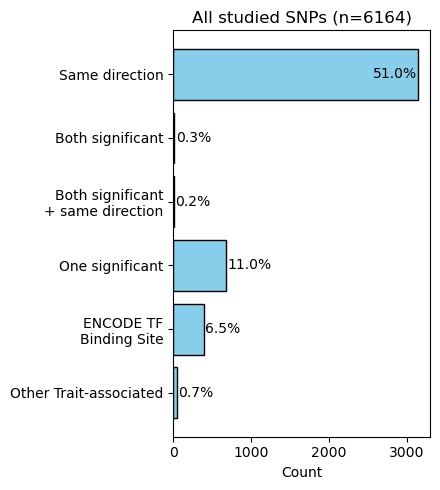

In [295]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(4.5, 5))


bars = ax1.barh(full_summary["Category"], full_summary["Count"], color="skyblue", edgecolor="black")
ax1.set_xlabel("Count")
ax1.set_ylabel("")

# Add percentages at the end of bars
for bar, perc in zip(bars, full_summary["Percentage"]):
    if perc > 20:
        ax1.text(bar.get_width() - 8, bar.get_y() + bar.get_height()/2,
				f"{perc:.1f}%", va="center", ha="right", color="black", fontsize=10)
    else:
        ax1.text(bar.get_width() + 17, bar.get_y() + bar.get_height()/2,
				f"{perc:.1f}%", va="center", fontsize=10)
plt.title(f"All studied SNPs (n={full_collapse_rsid.shape[0]})")
plt.tight_layout()



### Only considering those significant in at least one direction

In [290]:
onesig_collapse_rsid = full_collapse_rsid[full_collapse_rsid["Asthma OR COPD"] == 1]

# Get the conditions of interest
conditions = {
  	"Other Trait-associated": onesig_collapse_rsid["DA_Variants"].notna(),
    "ENCODE TF\nBinding Site": onesig_collapse_rsid["TFBS_Variants"].notna(),
    "Both significant\n+ same direction": ((onesig_collapse_rsid["Asthma AND COPD"] == 1) & 
                                          (onesig_collapse_rsid["same_direction"] == "Yes")),
    "Both significant": ((onesig_collapse_rsid["Asthma AND COPD"] == 1)),
    "Same direction": (onesig_collapse_rsid["same_direction"] == "Yes")
    
    
    
    
}

# --- Step 2: Build summary table ---
summary = pd.DataFrame([
    {"Category": name,
     "Count": cond.sum(),
     "Percentage": cond.mean() * 100}
    for name, cond in conditions.items()
])
summary


,Category,Count,Percentage
0,Other Trait-associated,44,6.461087
1,ENCODE TF\nBinding Site,398,58.443465
2,Both significant\n+ same direction,15,2.202643
3,Both significant,18,2.643172
4,Same direction,389,57.121880


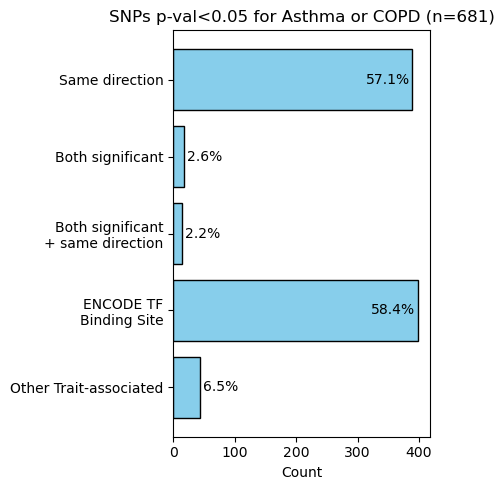

In [201]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4.5, 5))

bars = ax.barh(summary["Category"], summary["Count"], color="skyblue", edgecolor="black")
ax.set_xlabel("Count")
ax.set_ylabel("")

# Add percentages at the end of bars
for bar, perc in zip(bars, summary["Percentage"]):
    if perc > 20:
        ax.text(bar.get_width() - 4, bar.get_y() + bar.get_height()/2,
				f"{perc:.1f}%", va="center", ha="right", color="black", fontsize=10)
    else:
        ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
				f"{perc:.1f}%", va="center", fontsize=10)
plt.title(f"SNPs p-val<0.05 for Asthma or COPD (n={onesig_collapse_rsid.shape[0]})")
plt.tight_layout()
plt.show()

In [210]:
mask = onesig_collapse_rsid["DA_Traits"].astype(str).str.contains(r"FEV|lung|LUNG|smok|chronic obstructive", case=False, na=False)
filtered_df = onesig_collapse_rsid[mask]

filtered_df

,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,meta_p_weighted,same_direction,Unnamed: 13,Asthma,COPD,Asthma OR COPD,Asthma AND COPD,central_fixed,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj),Distance_to_Mu,TFBS_Variants,TFBS_TFs,TFBS_CellTypes,TFBS_Tissues,DA_OGVariants,DA_Variants,DA_Traits,DA_Betas,DA_PostProbs,DA_Assoc_types,DA_PredTargets,DA_PTScores,DA_LocusSizes,DA_Same_variants,DA_Sources,GT_Variants,GTs,GTs_Sources,GTs_Tissues,GTs_Same_Variants,GTs_Betas,GTs_PostProbs,GTs_Pvalues,GTs_UPM30_L2FC(padj),GTs_UPM120_L2FC(padj),GTs_WSP30_L2FC(padj),GTs_WSP120_L2FC(padj),ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_AAChanges,ME_distFtpts,ME_distTSS,ME_PredTargets,ME_EffectScores,ME_LofteeSiftPolyphen,CHMM_Variants,CHMM_Labels,CHMM_CellTypes,CHMM_Tissues,Gene 1 (5'),Gene 2 (3'),Nearest_Genes,NG_UPM30_L2FC(padj),NG_UPM120_L2FC(padj),NG_WSP30_L2FC(padj),NG_WSP120_L2FC(padj),TGT_AllCorr,TGT_B2BCorr,TGT_smAECCorr,TGT_DistTSS,TGT_DistTES,TGT_UPM30_L2FC(padj),TGT_UPM120_L2FC(padj),TGT_WSP30_L2FC(padj),TGT_WSP120_L2FC(padj)
194,19,55368493,55370326,chr19:55369334;chr19:55369987,LIET Gene TSS Intron;LIET Gene TSS Intergenic,55368504,rs1126757,0.9675,0.9772,0.093720,0.02534,0.010090,Yes,NaN,1,0,1,0,chr19:55369334;chr19:55369987,-1.83 (5.2e-02);-1.7 (9.4e-02),-1.1 (0.24);-0.2 (0.87),-0.63 (6.5e-04);-0.73 (3.8e-07),-1.01 (1.5e-08);-1.28 (2.9e-19),830;1483,19_55368504_C_A;19_55368504_C_G;19_55368504_C_T,POLR2A,"A549,Gliobla,HCT-116,IMR90,MCF-7,ProgFib,SK-N-...","Brain,Breast,Colon,Epithelium,Lung,Skin",None,19_55368504_C_T,smoking initiation;smoking status measurement,0.0094;0.0065,0.7015;0.7182,None,IL11,0.6435491473698643;0.7009207109472886,4.0,1.0,OT_GWAS_LD,19_55368504_C_A;19_55368504_C_G;19_55368504_C_T,BRSK1;COX6B2;FAM71E2;HSPBP1;IL11;ISOC2;KMT5C;P...,"Within loop,Within loop,Within loop,Within loo...","HUVEC,HMEC,KBM7,THP1_PMA,Spleen,HAP1_WAPL_KO,H...","True,True,True,True,True,True,True,True,True,T...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,na...","None,None,None,None,None,None,None,None,None,N...",None;-0.39 (1.1e-02);0.78 (7.6e-05);1.56 (1.1e...,None;-0.55 (5.2e-04);-0.05 (0.88);0.61 (0.18);...,-0.5 (1.1e-08);-1.66 (3.2e-48);None;-0.25 (7.8...,-0.69 (4.0e-15);-0.41 (2.1e-04);None;-0.54 (7....,19_55368504_C_T,synonymous_variant,VEP,None,0.0,-1959.0,IL11,"None,None,None",nan,19_55368504_C_A;19_55368504_C_G;19_55368504_C_T,Enh;EnhBiv;EnhG;TssA;TssAFlnk,"BRST.MYO,ESC.4STAR,IPSC.DF.6.9,MUS.HSMMT;ESC.H...","ESC,Epithelial,Muscle,iPSC;Digestive,ESC,Muscl...",IL11,IL11,IL11;IL11,1.56 (1.1e-05),0.61 (0.18),-0.95 (1.8e-39),-0.41 (8.3e-09),"IL11:NM_000641.4(0.67,0,87%), (0.81,0,83%), (-...","SSC5D:NM_001144950.2(0.58,0,87%), (0.92,0,83%)...","EDDM13:NM_001354658.2(-0.49,0.03,79%), (0,0.99...","IL11:NM_000641.4(0.67,0,87%), (0.81,0,83%), (-...","IL11:NM_000641.4(0.67,0,87%), (0.81,0,83%), (-...","1.56 (1.1e-05),1.11 (2.9e-06),1.17 (2.0e-02),1...","0.61 (0.18),-0.42 (0.17),0.1 (0.90),0.61 (0.18...","-0.95 (1.8e-39),-0.02 (0.82),NA,-0.95 (1.8e-39...","-0.41 (8.3e-09),-1.06 (6.5e-33),NA,-0.41 (8.3e..."
531,10,49538531,49539588,chr10:49538818;chr10:49539121;chr10:49539121;c...,LIET Gene TSS Intergenic;Gene TSS Bid;Gene TSS...,49539493,rs3793784,0.9503,0.9867,0.015920,0.22600,0.021276,Yes,NaN,0,1,1,0,chr10:49538818;chr10:49539121;chr10:49539121;c...,0.36 (0.14);NA;NA;NA;NA,-0.77 (2.0e-04);NA;NA;NA;NA,-0.16 (0.48);NA;NA;NA;NA,-1.02 (2.7e-08);NA;NA;NA;NA,-675;-372;-372;-372;45,10_49539493_G_C,CBX3;CTCF;E2F6;FOXA1;FOXA2;FOXM1;GATA3;HDAC1;J...,"K562;A549,AG09309,AG09319,AoAF,Caco-2,Dnd41,Fi...","Blood;Blood,Blood vessel,Brain,Breast,Cervix,C...",10_49539493_G_C,10_49539493_G_C,Age related macular degeneration 5;LUNG CANCER...,None,nan,risk factor,LOC130003807,nan,nan,True,Clinvar,10_49539493_G_C,C10orf71-AS1;ERCC6;RP11-123B3.2,"eqtl;eqtl,eqtl,eqtl,eqtl,eqtl,eqtl,eqtl,eqtl,e...","Skin Sun Exposed Lower leg;CD8-positive, alpha...","True;True,Fal